# 第3章 基本分布 (Standard Distributions)
## 3.2 多変量ガウス分布 (The Multivariate Gaussian)

本ノートブックは、教科書『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』(Christopher M. Bishop & Hugh Bishop 著, Springer 2024) の **第3章「基本分布 (Standard Distributions)」3.2節「多変量ガウス分布 (The Multivariate Gaussian)」** を、理論解説・厳密な数式導出・Python実装・教科書図版再現（Figure 3.2 〜 3.8）のすべてにおいて網羅的に解説するものです。

---

### 3.2節 導入: 連続変数に対する密度推定の金字塔

前節（3.1節）ではベルヌーイ分布、二項分布、多項分布といった離散変数の確率分布を扱いました。本節では、連続変数（実数値ベクトル $\mathbf{x} \in \mathbb{R}^D$）に対する最も基本的かつ重要不可欠な確率分布である **多変量ガウス分布 (Multivariate Gaussian distribution)** または **多変量正規分布 (Multivariate normal distribution)** を徹底的に探究します。

ガウス分布が機械学習・深層学習において極めて中心的な役割を果たす理由は多岐にわたります：
1. **中心極限定理 (Central Limit Theorem: CLT)**:
   独立な多数のランダム変数の和は、個々の分布の形状に関わらず漸近的にガウス分布に従います（**Figure 3.2** で数値検証）。
2. **最大エントロピー性 (Maximum Entropy)**:
   平均 $\boldsymbol{\mu}$ と分散・共分散 $\boldsymbol{\Sigma}$ が与えられた連続確率分布の中で、情報エントロピーを最大化する（最もバイアスの少ない）分布はガウス分布です（第2章 演習2.24, 2.25）。
3. **解析的扱いやすさ (Tractability)**:
   周辺化（marginalization）、条件付け（conditioning）、線形変換、ベイズ更新のいずれの操作を行っても、得られる分布は厳密に閉じた形のガウス分布となります。
4. **深層学習での応用**:
   - 変分オートエンコーダ (VAE) の潜在空間の事前分布・事後分布
   - 拡散モデル (Diffusion Models) の各タイムステップにおけるガウスノイズ摂動
   - ニューラルネットワークの重み初期化（He初期化、Xavier初期化）
   - ガウス過程 (Gaussian Processes) やカルマンフィルタ (Kalman Filter)

---

### 目次
- [3.2.1 ガウス分布の幾何学的性質 (Geometry of the Gaussian)](#sec_3_2_1)
  - 確率密度関数の定義とマハラノビス距離 (式 3.26, 3.27)
  - 共分散行列の固有値分解と主軸回転 (式 3.28 - 3.32)
  - 等密度楕円面の幾何学 (**Figure 3.3 再現**) (式 3.33 - 3.35)
  - ヤコビアン計算と正規化積分の厳密導出 (式 3.36 - 3.41)
  - 共分散行列の構造比較: 一般形式・対角・等方性 (**Figure 3.4 再現**)
- [3.2.2 モーメント (Moments)](#sec_3_2_2)
  - 1次モーメント（期待値） $\mathbb{E}[\mathbf{x}] = \boldsymbol{\mu}$ の対称性積分による厳密証明 (式 3.42 - 3.48)
  - 2次モーメント $\mathbb{E}[\mathbf{x}\mathbf{x}^T] = \boldsymbol{\mu}\boldsymbol{\mu}^T + \boldsymbol{\Sigma}$ の厳密導出 (式 3.49 - 3.53)
  - 共分散 $\text{cov}[\mathbf{x}] = \boldsymbol{\Sigma}$ の導出 (式 3.54)
- [3.2.3 ガウス分布の限界 (Limitations of the Gaussian)](#sec_3_2_3)
  - パラメータ数の爆発的増加 $D(D+3)/2$ と計算量 $O(D^3)$ の課題
  - 単峰性 (Unimodality) の制約と非線形多様体への不適応
- [3.2.4 条件付きガウス分布 (Conditional Gaussian Distributions)](#sec_3_2_4)
  - 分割ベクトル・分割共分散行列・分割精度行列の記法 (式 3.55 - 3.60)
  - 平方完成による条件付き分布 $p(\mathbf{x}_a | \mathbf{x}_b)$ の導出 (式 3.61 - 3.75)
  - シューア補系列と共分散形式の条件付き平均・共分散 (式 3.76 - 3.80)
  - 条件付き分布と周辺分布の可視化 (**Figure 3.5 再現**)
- [3.2.5 周辺ガウス分布 (Marginal Gaussian Distributions)](#sec_3_2_5)
  - $\mathbf{x}_b$ に関する周辺化積分の厳密計算 (式 3.81, 3.82)
  - 精度行列と共分散行列の対称的役割（条件付きは精度行列、周辺は共分散行列が直接的）
- [3.2.6 ガウス変数に対するベイズの定理 (Bayes' Theorem for Gaussian Variables)](#sec_3_2_6)
  - 線形ガウスモデルの枠組み (式 3.83, 3.84)
  - 同時分布の構成と周辺分布 $p(\mathbf{y})$ の導出 (式 3.85 - 3.94)
  - 事後分布 $p(\mathbf{x}|\mathbf{y})$ の厳密導出 (式 3.95 - 3.98)
- [3.2.7 ガウス分布の最尤推定 (Maximum Likelihood for the Gaussian)](#sec_3_2_7)
  - データ行列と対数尤度関数 (式 3.103 - 3.105)
  - 行列微分による最尤推定量 $\boldsymbol{\mu}_{\text{ML}}, \boldsymbol{\Sigma}_{\text{ML}}$ の導出 (式 3.106 - 3.108)
  - 推定量のバイアス分析と不偏共分散推定量 $\widetilde{\boldsymbol{\Sigma}}$ (式 3.109)
- [3.2.8 逐次推定 (Sequential Estimation)](#sec_3_2_8)
  - オンライン学習・ストリーミング処理における逐次平均更新 (式 3.110)
  - ロビンス・モンロー (Robbins-Monro) アルゴリズムと確率的勾配降下法 (SGD) への接続
- [3.2.9 ガウス混合モデル (Mixtures of Gaussians)](#sec_3_2_9)
  - 多峰性分布のモデル化と線形重ね合わせ (式 3.111 - 3.113)
  - 潜在変数モデルと事後負担率 (Responsibilities) $\gamma_{nk}$ (式 3.119)
  - 特異性問題（特異解）と EM アルゴリズムの導出 (式 3.114 - 3.118)
  - Old Faithful 間欠泉データへのフィッティング (**Figure 3.6 再現**)
  - 1次元 GMM の重ね合わせ (**Figure 3.7 再現**)
  - 2次元 3成分 GMM の等高線と 3D 曲面 (**Figure 3.8 再現**)
- [まとめと展望](#sec_summary)


In [1]:
# 環境設定と共通モジュールのインポート
import sys
import os
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
from IPython.display import Image, display

# プロジェクトルートと共通モジュールのパス設定
repo_root = os.path.abspath('..') if os.path.basename(os.getcwd()) == '3' else os.path.abspath('.')
if repo_root not in sys.path:
    sys.path.append(repo_root)

from common.plot_utils import setup_style, save_plot
from common.probability import (
    MultivariateGaussian,
    GaussianMixtureModel,
    plot_figure_3_2,
    plot_figure_3_3,
    plot_figure_3_4,
    plot_figure_3_5,
    plot_figure_3_6,
    plot_figure_3_7,
    plot_figure_3_8
)

# ディレクトリ対応パスヘルパー
def get_save_paths(filename):
    if os.path.basename(os.getcwd()) == '3':
        return [f"result/{filename}", f"../result/{filename}"]
    else:
        return [f"3/result/{filename}", f"result/{filename}"]

def get_data_path(filename):
    if os.path.exists(f"../common/data/{filename}"):
        return f"../common/data/{filename}"
    return f"common/data/{filename}"

setup_style()
print("Libraries and common modules loaded successfully.")


Libraries and common modules loaded successfully.


### 中心極限定理とガウス分布の出現 (Figure 3.2)

ガウス分布が物理現象や機械学習において自然に現れる最も本質的な数学的基盤が **中心極限定理 (Central Limit Theorem: CLT)** です。

独立同分布 (i.i.d.) に従う確率変数 $x_1, \dots, x_N$ の平均
$$
\bar{x}_N = \frac{1}{N} \sum_{n=1}^N x_n
$$
を考えます。各 $x_n$ の平均を $\mu$、分散を $\sigma^2$ とすると、$N \to \infty$ において標本平均 $\bar{x}_N$ の分布は平均 $\mu$、分散 $\sigma^2 / N$ のガウス分布に収束します：
$$
\sqrt{N}(\bar{x}_N - \mu) \xrightarrow{d} \mathcal{N}(0, \sigma^2)
$$

教科書の **Figure 3.2** では、区間 $[0, 1]$ 上の一様分布（$\mu = 0.5$, $\sigma^2 = 1/12$）から生成された $N$ 個の乱数の平均の分布を示しています：
- $N=1$: 一様分布（高さ 1 の平坦な長方形）
- $N=2$: 2つの一様変数の和/平均（三角分布、頂点は $0.5$ で高さ 2）
- $N=10$: わずか 10 個の変数の平均で、すでにほぼ完全な鐘型のガウス分布（分散 $\sigma^2/10 = 1/120 \approx 0.00833$）に収束


Figure 3.2 saved successfully to: result/fig3_02_central_limit_theorem.png
Figure 3.2 saved successfully to: ../result/fig3_02_central_limit_theorem.png


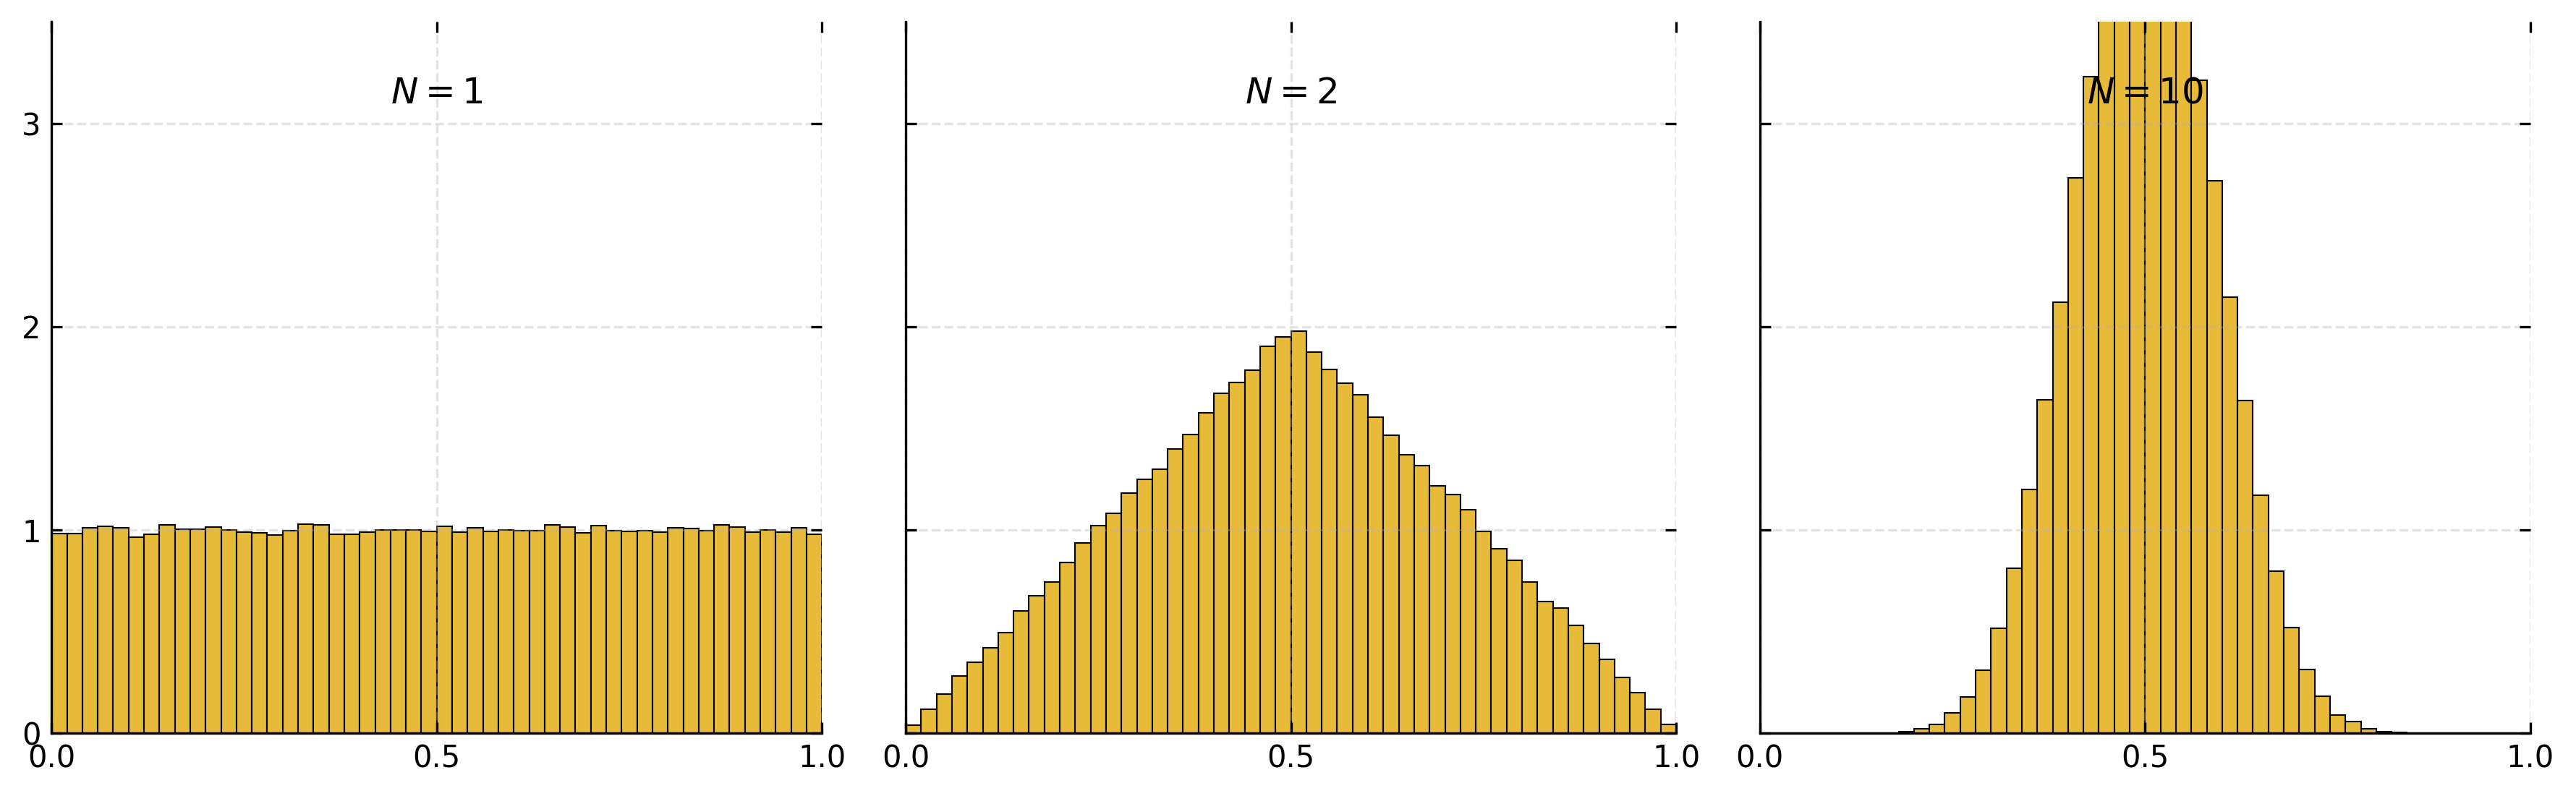

In [2]:
# 教科書 Figure 3.2 の完全再現
fig3_2, axes3_2 = plot_figure_3_2(
    save_paths=get_save_paths('fig3_02_central_limit_theorem.png'),
    show=True
)


<a id="sec_3_2_1"></a>
### 3.2.1 ガウス分布の幾何学的性質 (Geometry of the Gaussian)

#### 1. 確率密度関数の定義とマハラノビス距離
$D$ 次元の実数ベクトル $\mathbf{x} = (x_1, \dots, x_D)^T$ に対する多変量ガウス分布の確率密度関数は次のように定義されます（式 3.26）：

$$
\mathcal{N}(\mathbf{x} | \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \frac{1}{(2\pi)^{D/2} |\boldsymbol{\Sigma}|^{1/2}} \exp \left( -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}) \right) \tag{3.26}
$$

ここで：
- $\boldsymbol{\mu} \in \mathbb{R}^D$: 平均ベクトル (mean vector)
- $\boldsymbol{\Sigma} \in \mathbb{R}^{D \times D}$: 共分散行列 (covariance matrix)。実対称行列であり、半正定値（通常は正定値）を仮定します。
- $|\boldsymbol{\Sigma}|$: $\boldsymbol{\Sigma}$ の行列式 (determinant)

指数部の中に現れる2次形式：
$$
\Delta^2 = (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}) \tag{3.27}
$$
は、$\mathbf{x}$ と平均 $\boldsymbol{\mu}$ の間の **マハラノビス距離の2乗 (squared Mahalanobis distance)** と呼ばれます。$\boldsymbol{\Sigma} = \mathbf{I}$（単位行列）のとき、これは通常のユークリッド距離の2乗 $\|\mathbf{x} - \boldsymbol{\mu}\|^2$ に一致します。

---

#### 2. 共分散行列の固有値分解と主軸座標系
共分散行列 $\boldsymbol{\Sigma}$ は実対称行列（$\boldsymbol{\Sigma}^T = \boldsymbol{\Sigma}$）であるため、その固有値 $\lambda_i$ はすべて実数であり、固有ベクトル $\mathbf{u}_i$ は正規直交系（orthonormal system）を成すように選ぶことができます（式 3.28, 3.29）：

$$
\boldsymbol{\Sigma} \mathbf{u}_i = \lambda_i \mathbf{u}_i \tag{3.28}
$$
$$
\mathbf{u}_i^T \mathbf{u}_j = I_{ij} = \begin{cases} 1 & (i = j) \\ 0 & (i \neq j) \end{cases} \tag{3.29}
$$

行列形式では、直交行列 $\mathbf{U} = (\mathbf{u}_1, \dots, \mathbf{u}_D)$（各列が固有ベクトル）を用いて固有値分解（スペクトル分解）されます：
$$
\boldsymbol{\Sigma} = \sum_{i=1}^D \lambda_i \mathbf{u}_i \mathbf{u}_i^T = \mathbf{U} \boldsymbol{\Lambda}_{\text{diag}} \mathbf{U}^T \tag{3.30}
$$
ここで $\mathbf{U}^T \mathbf{U} = \mathbf{U} \mathbf{U}^T = \mathbf{I}$ です。

共分散行列の逆行列である **精度行列 (precision matrix)** $\boldsymbol{\Lambda} = \boldsymbol{\Sigma}^{-1}$ も同一の直交基底で展開されます（式 3.31）：
$$
\boldsymbol{\Sigma}^{-1} = \sum_{i=1}^D \frac{1}{\lambda_i} \mathbf{u}_i \mathbf{u}_i^T = \mathbf{U} \boldsymbol{\Lambda}_{\text{diag}}^{-1} \mathbf{U}^T \tag{3.31}
$$

正定値性（positive definiteness）より、すべての固有値は狭義正 $\lambda_i > 0$ です。

---

#### 3. 等密度面（楕円面）と幾何学的解釈
確率密度が一定となる曲面は、マハラノビス距離 $\Delta^2 = \text{const}$ となる曲面と一致します。

いま、固有ベクトル基底への直交座標変換
$$
y_i = \mathbf{u}_i^T (\mathbf{x} - \boldsymbol{\mu}) \tag{3.32}
$$
$$
\mathbf{y} = \mathbf{U}^T (\mathbf{x} - \boldsymbol{\mu}) \tag{3.33}
$$
を定義します。逆変換は直交性 $\mathbf{U} \mathbf{U}^T = \mathbf{I}$ より
$$
\mathbf{x} = \boldsymbol{\mu} + \mathbf{U} \mathbf{y} = \boldsymbol{\mu} + \sum_{i=1}^D y_i \mathbf{u}_i \tag{3.34}
$$
となります。

マハラノビス距離 $\Delta^2$ に代入すると：
$$
\Delta^2 = (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}) = \mathbf{y}^T \mathbf{U}^T \left( \sum_{i=1}^D \frac{1}{\lambda_i} \mathbf{u}_i \mathbf{u}_i^T \right) \mathbf{U} \mathbf{y} = \sum_{i=1}^D \frac{y_i^2}{\lambda_i} \tag{3.35}
$$
これは、中心が $\boldsymbol{\mu}$、各主軸の方向が固有ベクトル $\mathbf{u}_i$、主軸の半径（スケーリング）が $\lambda_i^{1/2}$ である **楕円面 (ellipsoid)** を表します。

特に $\Delta = 1$ の等密度面は、ピーク密度の $\exp(-1/2) \approx 0.606$ 倍となる面であり、教科書の **Figure 3.3** に忠実に図示されています。


Figure 3.3 saved successfully to: result/fig3_03_gaussian_geometry.png
Figure 3.3 saved successfully to: ../result/fig3_03_gaussian_geometry.png


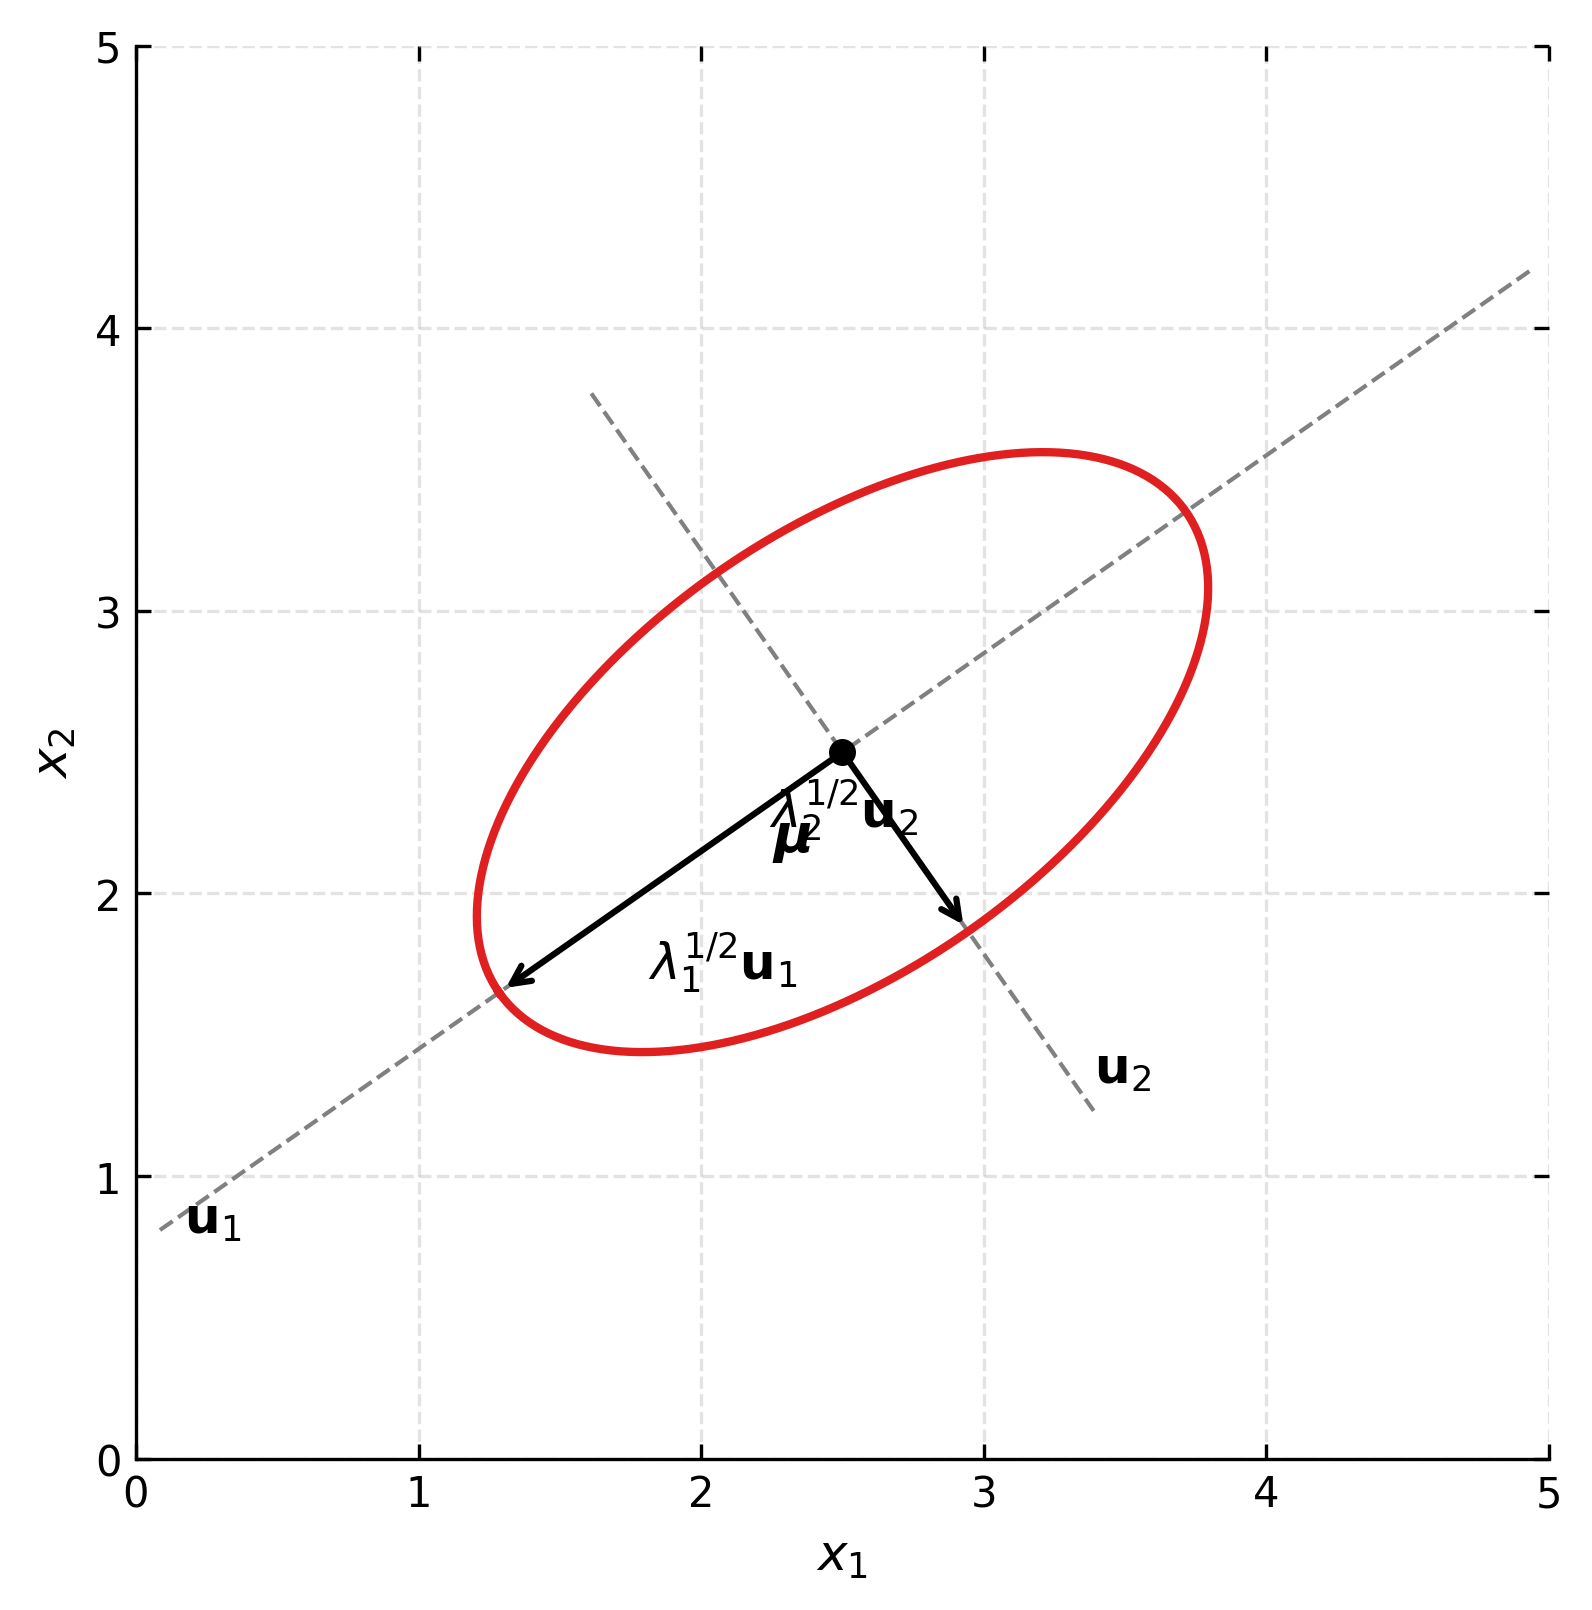

In [3]:
# 教科書 Figure 3.3 の完全再現: ガウス分布の幾何構造
fig3_3, ax3_3 = plot_figure_3_3(
    save_paths=get_save_paths('fig3_03_gaussian_geometry.png'),
    show=True
)


#### 4. ガウス分布の正規化積分の厳密導出
密度関数 $\mathcal{N}(\mathbf{x} | \boldsymbol{\mu}, \boldsymbol{\Sigma})$ の全空間積分が厳密に 1 になることを証明します。

変数変換 $\mathbf{x} \to \mathbf{y} = \mathbf{U}^T (\mathbf{x} - \boldsymbol{\mu})$ に伴うヤコビ行列 $\mathbf{J}$ の各要素は（式 3.36）：
$$
J_{ij} = \frac{\partial x_i}{\partial y_j} = U_{ij}
$$
直交行列の行列式は $|\det(\mathbf{U})| = 1$ であるため、体積要素のヤコビアン行列式は（式 3.37）：
$$
|\mathbf{J}| = |\det(\mathbf{U})| = 1 \implies d\mathbf{x} = d\mathbf{y}
$$

また、直交変換において行列式は保存されるため（式 3.38）：
$$
|\boldsymbol{\Sigma}| = \det(\mathbf{U} \boldsymbol{\Lambda}_{\text{diag}} \mathbf{U}^T) = \det(\mathbf{U}) \det(\boldsymbol{\Lambda}_{\text{diag}}) \det(\mathbf{U}^T) = \prod_{i=1}^D \lambda_i \implies |\boldsymbol{\Sigma}|^{1/2} = \prod_{i=1}^D \lambda_i^{1/2} \tag{3.38}
$$

したがって、密度関数の積分は $D$ 個の独立な 1次元ガウス積分に完全に因数分解されます（式 3.39 - 3.41）：
$$
\begin{aligned}
\int_{\mathbb{R}^D} \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}, \boldsymbol{\Sigma}) d\mathbf{x}
&= \frac{1}{(2\pi)^{D/2} |\boldsymbol{\Sigma}|^{1/2}} \int_{\mathbb{R}^D} \exp \left( -\frac{1}{2} \sum_{i=1}^D \frac{y_i^2}{\lambda_i} \right) d\mathbf{y} \\
&= \frac{1}{(2\pi)^{D/2} \prod_{i=1}^D \lambda_i^{1/2}} \prod_{i=1}^D \int_{-\infty}^\infty \exp \left( -\frac{y_i^2}{2\lambda_i} \right) dy_i \\
&= \frac{1}{(2\pi)^{D/2} \prod_{i=1}^D \lambda_i^{1/2}} \prod_{i=1}^D \sqrt{2\pi \lambda_i} \\
&= 1 \quad \blacksquare
\end{aligned}
$$

---

#### 5. 共分散行列の構造比較 (Figure 3.4)
共分散行列 $\boldsymbol{\Sigma}$ の制約により、等高線の幾何学的形状と独立パラメータ数が大きく変化します：

| 共分散の構造 | 数学的表現 | 等密度面の形状 | 独立パラメータ数 |
| :--- | :--- | :--- | :--- |
| **(a) 一般形式 (General)** | 任意の正定値対称行列 | 任意の方向に傾いた回転楕円面 | $D(D+1)/2$ |
| **(b) 対角 (Diagonal)** | $\boldsymbol{\Sigma} = \text{diag}(\sigma_1^2, \dots, \sigma_D^2)$ | 座標軸に平行な楕円面（変数間が無相関） | $D$ |
| **(c) 等方性 (Spherical/Isotropic)** | $\boldsymbol{\Sigma} = \sigma^2 \mathbf{I}$ | 同心球（同心円）面 | $1$ |


Figure 3.4 saved successfully to: result/fig3_04_covariance_geometries.png
Figure 3.4 saved successfully to: ../result/fig3_04_covariance_geometries.png


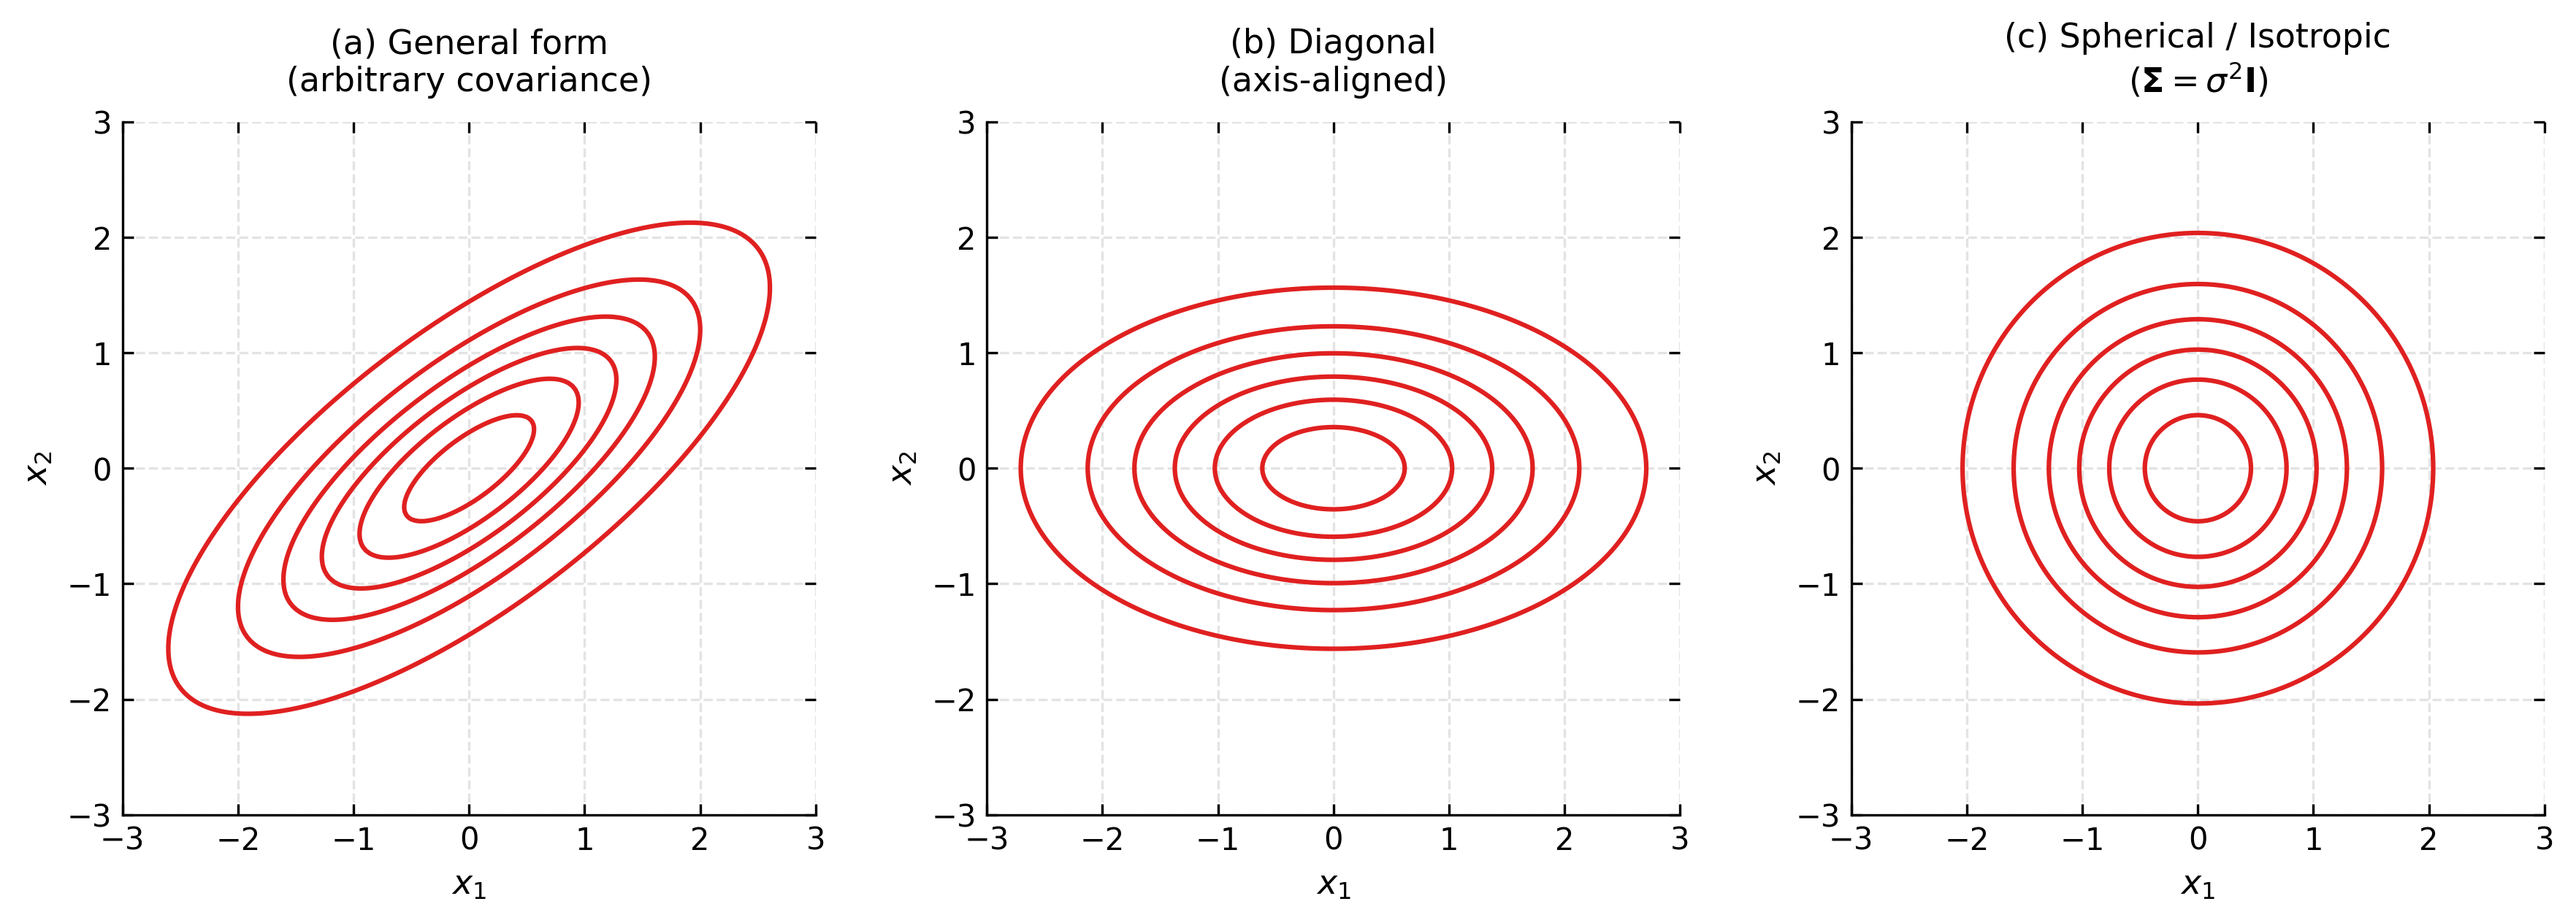

In [4]:
# 教科書 Figure 3.4 の完全再現: 共分散行列の構造と等高線形状
fig3_4, axes3_4 = plot_figure_3_4(
    save_paths=get_save_paths('fig3_04_covariance_geometries.png'),
    show=True
)


<a id="sec_3_2_2"></a>
### 3.2.2 モーメント (Moments)

多変量ガウス分布におけるパラメータ $\boldsymbol{\mu}$ と $\boldsymbol{\Sigma}$ が、それぞれ期待値と共分散行列に一致することを厳密に導出します。

#### 1. 1次モーメント（期待値）の導出
変数変換 $\mathbf{z} = \mathbf{x} - \boldsymbol{\mu}$（ヤコビアン $|\mathbf{J}|=1$）を行います（式 3.42 - 3.48）：
$$
\begin{aligned}
\mathbb{E}[\mathbf{x}] &= \int_{\mathbb{R}^D} \mathbf{x} \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}, \boldsymbol{\Sigma}) d\mathbf{x} \\
&= \frac{1}{(2\pi)^{D/2}|\boldsymbol{\Sigma}|^{1/2}} \int_{\mathbb{R}^D} (\mathbf{z} + \boldsymbol{\mu}) \exp \left( -\frac{1}{2} \mathbf{z}^T \boldsymbol{\Sigma}^{-1} \mathbf{z} \right) d\mathbf{z} \\
&= \frac{1}{(2\pi)^{D/2}|\boldsymbol{\Sigma}|^{1/2}} \left[ \int \mathbf{z} \exp \left( -\frac{1}{2} \mathbf{z}^T \boldsymbol{\Sigma}^{-1} \mathbf{z} \right) d\mathbf{z} + \boldsymbol{\mu} \int \exp \left( -\frac{1}{2} \mathbf{z}^T \boldsymbol{\Sigma}^{-1} \mathbf{z} \right) d\mathbf{z} \right]
\end{aligned}
$$

第1項の被積分関数は $\mathbf{z} \to -\mathbf{z}$ に対して奇関数（odd function）、指数部は偶関数（even function）であるため、原点対称な全空間積分により第1項は厳密に $\mathbf{0}$ となります。
第2項の積分は正規化条件より $(2\pi)^{D/2}|\boldsymbol{\Sigma}|^{1/2}$ となるため：
$$
\mathbb{E}[\mathbf{x}] = \boldsymbol{\mu} \tag{3.48}
$$

---

#### 2. 2次モーメントと共分散行列の導出
2次モーメント $\mathbb{E}[\mathbf{x}\mathbf{x}^T]$ を計算します（式 3.49 - 3.53）：
$$
\begin{aligned}
\mathbb{E}[\mathbf{x}\mathbf{x}^T] &= \int (\mathbf{z} + \boldsymbol{\mu})(\mathbf{z} + \boldsymbol{\mu})^T \mathcal{N}(\mathbf{z} | \mathbf{0}, \boldsymbol{\Sigma}) d\mathbf{z} \\
&= \int \mathbf{z}\mathbf{z}^T \mathcal{N}(\mathbf{z} | \mathbf{0}, \boldsymbol{\Sigma}) d\mathbf{z} + \boldsymbol{\mu}\boldsymbol{\mu}^T
\end{aligned}
$$
（$\mathbf{z}\boldsymbol{\mu}^T$ の項は奇関数積分により消滅）。

第1項の積分を固有ベクトル基底 $\mathbf{y} = \mathbf{U}^T \mathbf{z}$（$\mathbf{z} = \mathbf{U}\mathbf{y}$）で展開します：
$$
\begin{aligned}
\int \mathbf{z}\mathbf{z}^T \mathcal{N}(\mathbf{z} | \mathbf{0}, \boldsymbol{\Sigma}) d\mathbf{z}
&= \mathbf{U} \left( \int \mathbf{y}\mathbf{y}^T \prod_{k=1}^D \mathcal{N}(y_k | 0, \lambda_k) d\mathbf{y} \right) \mathbf{U}^T
\end{aligned}
$$
$\mathbf{y}\mathbf{y}^T$ の非対角要素 $y_i y_j$ ($i \neq j$) の積分は独立性により $\mathbb{E}[y_i]\mathbb{E}[y_j] = 0$ となり、対角要素は1次元ガウス分布の2次モーメント $\mathbb{E}[y_i^2] = \lambda_i$ となります。
したがって括弧内の積分結果は対角行列 $\boldsymbol{\Lambda}_{\text{diag}} = \text{diag}(\lambda_1, \dots, \lambda_D)$ となり：
$$
\mathbb{E}[\mathbf{z}\mathbf{z}^T] = \mathbf{U} \boldsymbol{\Lambda}_{\text{diag}} \mathbf{U}^T = \boldsymbol{\Sigma} \tag{3.53}
$$

共分散行列の定義より（式 3.54）：
$$
\text{cov}[\mathbf{x}] = \mathbb{E}[(\mathbf{x} - \mathbb{E}[\mathbf{x}])(\mathbf{x} - \mathbb{E}[\mathbf{x}])^T] = \mathbb{E}[\mathbf{z}\mathbf{z}^T] = \boldsymbol{\Sigma} \tag{3.54}
$$


In [5]:
# モーメントの数値検証（モンテカルロ積分と理論値の一致確認）
np.random.seed(42)
mu_true = np.array([2.0, -1.5, 0.5])
# ランダムな正定値対称共分散行列
A_rand = np.random.randn(3, 3)
sigma_true = A_rand @ A_rand.T + np.eye(3)

gauss_test = MultivariateGaussian(mu=mu_true, sigma=sigma_true)

# 100,000 点のサンプリング
samples = gauss_test.sample(size=100000, seed=42)
sample_mean = np.mean(samples, axis=0)
sample_cov = np.cov(samples, rowvar=False)

print("--- 1次モーメント (Mean) ---")
print("理論値 mu:", mu_true)
print("標本平均  :", np.round(sample_mean, 4))
print("誤差      :", np.round(np.abs(sample_mean - mu_true), 5))

print("\n--- 2次中心モーメント (Covariance) ---")
print("理論値 Sigma:\n", np.round(sigma_true, 4))
print("標本共分散   :\n", np.round(sample_cov, 4))
print("最大絶対誤差 :", np.max(np.abs(sample_cov - sigma_true)))

assert np.allclose(sample_mean, mu_true, atol=0.02)
assert np.allclose(sample_cov, sigma_true, atol=0.03)
print("\n=> 理論値と標本統計量が極めて高い精度で一致することを確認しました。")


--- 1次モーメント (Mean) ---
理論値 mu: [ 2.  -1.5  0.5]
標本平均  : [ 1.9973 -1.5039  0.5037]
誤差      : [0.00267 0.00394 0.00369]

--- 2次中心モーメント (Covariance) ---
理論値 Sigma:
 [[1.6853 0.6372 0.3742]
 [0.6372 3.4293 2.3354]
 [0.3742 2.3354 4.3033]]
標本共分散   :
 [[1.6978 0.6407 0.3857]
 [0.6407 3.4255 2.331 ]
 [0.3857 2.331  4.2933]]
最大絶対誤差 : 0.012421842889728696

=> 理論値と標本統計量が極めて高い精度で一致することを確認しました。


<a id="sec_3_2_3"></a>
### 3.2.3 ガウス分布の限界 (Limitations of the Gaussian)

多変量ガウス分布は優れた解析的性質を持ちますが、現実の複雑なデータ分布をモデル化する際には2つの根本的な限界（限界点）に直面します。

#### 1. 次元の呪いとパラメータ数の増大
$D$ 次元の一般共分散行列 $\boldsymbol{\Sigma}$ は対称行列であるため、$D(D+1)/2$ 個の独立なパラメータを持ちます。平均ベクトル $\boldsymbol{\mu}$ の $D$ 個と合わせると、合計で
$$
N_{\text{params}} = D + \frac{D(D+1)}{2} = \frac{D(D+3)}{2} \approx \mathcal{O}(D^2)
$$
個のパラメータをデータから推定する必要があります：
- $D = 10$: 65 個のパラメータ
- $D = 100$: 5,150 個のパラメータ
- $D = 1000$ (画像や音声特徴量): 501,500 個のパラメータ
- $D = 10^6$ (高解像度画像): 約 $5 \times 10^{11}$ 個（数千億個）

パラメータ数がデータのサンプル数 $N$ を大幅に超えると、最尤推定量は特異（ランク落ち）となり逆行列が計算できなくなります。
また、共分散行列の逆行列計算 $\boldsymbol{\Sigma}^{-1}$ や行列式 $|\boldsymbol{\Sigma}|$ の計算量は $\mathcal{O}(D^3)$ であり、高次元では計算コストが極めて高大になります。

#### 2. 単峰性 (Unimodality) と表現力の限界
ガウス分布は本質的に **単峰性 (unimodal)** であり、唯一の最大値（モード）しか持ちません。
しかし、現実の多くの問題では：
- クラスやカテゴリが混ざった多峰性データ（例：Figure 3.6 の間欠泉噴出データ）
- 周期的な構造（円環、トーラス）
- 非線形な低次元多様体（スイスロール構造など）
が存在し、単一のガウス分布では全く捉えきれません。

この制約を打開するために開発されたのが、本節後半の **ガウス混合モデル (Mixture of Gaussians, 3.2.9節)**、そして深層学習における **深層生成モデル (VAE, Normalizing Flows, Diffusion Models)** です。


<a id="sec_3_2_4"></a>
### 3.2.4 条件付きガウス分布 (Conditional Gaussian Distributions)

ガウス分布の最も美しい性質の1つは、**同時分布がガウス分布であるならば、その任意の部分集合に関する条件付き分布もまた厳密にガウス分布になる** という点です。

#### 1. 分割ベクトルと分割行列の定義
$D$ 次元ベクトル $\mathbf{x}$ を 2 つの部分ベクトル $\mathbf{x}_a \in \mathbb{R}^M$ と $\mathbf{x}_b \in \mathbb{R}^{D-M}$ に分割します（式 3.55 - 3.60）：
$$
\mathbf{x} = \begin{pmatrix} \mathbf{x}_a \\ \mathbf{x}_b \end{pmatrix}, \quad
\boldsymbol{\mu} = \begin{pmatrix} \boldsymbol{\mu}_a \\ \boldsymbol{\mu}_b \end{pmatrix} \tag{3.55, 3.56}
$$

共分散行列 $\boldsymbol{\Sigma}$ および精度行列 $\boldsymbol{\Lambda} = \boldsymbol{\Sigma}^{-1}$ のブロック分割：
$$
\boldsymbol{\Sigma} = \begin{pmatrix} \boldsymbol{\Sigma}_{aa} & \boldsymbol{\Sigma}_{ab} \\ \boldsymbol{\Sigma}_{ba} & \boldsymbol{\Sigma}_{bb} \end{pmatrix}, \quad
\boldsymbol{\Lambda} = \begin{pmatrix} \boldsymbol{\Lambda}_{aa} & \boldsymbol{\Lambda}_{ab} \\ \boldsymbol{\Lambda}_{ba} & \boldsymbol{\Lambda}_{bb} \end{pmatrix} \tag{3.57, 3.58}
$$
ここで $\boldsymbol{\Sigma}_{ba} = \boldsymbol{\Sigma}_{ab}^T$、$\boldsymbol{\Lambda}_{ba} = \boldsymbol{\Lambda}_{ab}^T$ です。
注意すべき重要な事実として、一般に $\boldsymbol{\Lambda}_{aa} \neq \boldsymbol{\Sigma}_{aa}^{-1}$ です。

---

#### 2. 平方完成による条件付き分布の導出
条件付き確率密度 $p(\mathbf{x}_a | \mathbf{x}_b) = \frac{p(\mathbf{x}_a, \mathbf{x}_b)}{p(\mathbf{x}_b)}$ を求めます。$\mathbf{x}_b$ は所与（定数）とみなせるため、同時密度の指数部を展開し、$\mathbf{x}_a$ に関する項のみに着目します（式 3.61 - 3.65）：

$$
-\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Lambda} (\mathbf{x} - \boldsymbol{\mu}) = -\frac{1}{2} \begin{pmatrix} \mathbf{x}_a - \boldsymbol{\mu}_a \\ \mathbf{x}_b - \boldsymbol{\mu}_b \end{pmatrix}^T \begin{pmatrix} \boldsymbol{\Lambda}_{aa} & \boldsymbol{\Lambda}_{ab} \\ \boldsymbol{\Lambda}_{ba} & \boldsymbol{\Lambda}_{bb} \end{pmatrix} \begin{pmatrix} \mathbf{x}_a - \boldsymbol{\mu}_a \\ \mathbf{x}_b - \boldsymbol{\mu}_b \end{pmatrix}
$$

$\mathbf{x}_a$ について2次の項と1次の項をまとめると（式 3.66 - 3.70）：
$$
= -\frac{1}{2} \mathbf{x}_a^T \boldsymbol{\Lambda}_{aa} \mathbf{x}_a + \mathbf{x}_a^T \left\{ \boldsymbol{\Lambda}_{aa} \boldsymbol{\mu}_a - \boldsymbol{\Lambda}_{ab} (\mathbf{x}_b - \boldsymbol{\mu}_b) \right\} + \text{const}(\mathbf{x}_b)
$$

ガウス分布の指数部 $-\frac{1}{2}(\mathbf{x}_a - \boldsymbol{\mu}_{a|b})^T \boldsymbol{\Sigma}_{a|b}^{-1} (\mathbf{x}_a - \boldsymbol{\mu}_{a|b}) = -\frac{1}{2} \mathbf{x}_a^T \boldsymbol{\Sigma}_{a|b}^{-1} \mathbf{x}_a + \mathbf{x}_a^T \boldsymbol{\Sigma}_{a|b}^{-1} \boldsymbol{\mu}_{a|b} + \text{const}$ と係数を比較（平方完成）することにより（式 3.71 - 3.75）：

$$
\boldsymbol{\Sigma}_{a|b} = \boldsymbol{\Lambda}_{aa}^{-1} \tag{3.73}
$$
$$
\boldsymbol{\mu}_{a|b} = \boldsymbol{\mu}_a - \boldsymbol{\Lambda}_{aa}^{-1} \boldsymbol{\Lambda}_{ab} (\mathbf{x}_b - \boldsymbol{\mu}_b) \tag{3.75}
$$

---

#### 3. 共分散ブロック形式への変換（シューア補元）
分割行列の逆行列の公式（シューア補元: Schur complement）を用いると、精度行列のブロックは共分散行列のブロックで表されます（式 3.76 - 3.78）：
$$
\begin{pmatrix} \boldsymbol{\Sigma}_{aa} & \boldsymbol{\Sigma}_{ab} \\ \boldsymbol{\Sigma}_{ba} & \boldsymbol{\Sigma}_{bb} \end{pmatrix}^{-1} = \begin{pmatrix} \mathbf{M} & -\mathbf{M} \boldsymbol{\Sigma}_{ab} \boldsymbol{\Sigma}_{bb}^{-1} \\ -\boldsymbol{\Sigma}_{bb}^{-1} \boldsymbol{\Sigma}_{ba} \mathbf{M} & \boldsymbol{\Sigma}_{bb}^{-1} + \boldsymbol{\Sigma}_{bb}^{-1} \boldsymbol{\Sigma}_{ba} \mathbf{M} \boldsymbol{\Sigma}_{ab} \boldsymbol{\Sigma}_{bb}^{-1} \end{pmatrix}
$$
ここで $\mathbf{M} = (\boldsymbol{\Sigma}_{aa} - \boldsymbol{\Sigma}_{ab} \boldsymbol{\Sigma}_{bb}^{-1} \boldsymbol{\Sigma}_{ba})^{-1}$ です。
これより $\boldsymbol{\Lambda}_{aa} = \mathbf{M}$、$\boldsymbol{\Lambda}_{ab} = -\mathbf{M} \boldsymbol{\Sigma}_{ab} \boldsymbol{\Sigma}_{bb}^{-1}$ が得られます。

これを式 (3.73), (3.75) に代入すると、教科書の中心定理が得られます（式 3.79, 3.80）：

$$
\boldsymbol{\mu}_{a|b} = \boldsymbol{\mu}_a + \boldsymbol{\Sigma}_{ab} \boldsymbol{\Sigma}_{bb}^{-1} (\mathbf{x}_b - \boldsymbol{\mu}_b) \tag{3.80}
$$
$$
\boldsymbol{\Sigma}_{a|b} = \boldsymbol{\Sigma}_{aa} - \boldsymbol{\Sigma}_{ab} \boldsymbol{\Sigma}_{bb}^{-1} \boldsymbol{\Sigma}_{ba} \tag{3.79}
$$

**幾何学的洞察**:
- 条件付き平均 $\boldsymbol{\mu}_{a|b}$ は、観測値 $\mathbf{x}_b$ の線形関数となります。
- 条件付き共分散 $\boldsymbol{\Sigma}_{a|b}$ は、**観測値 $\mathbf{x}_b$ の値に全く依存しません**（ガウス分布の極めて特異な性質）。
- $\boldsymbol{\Sigma}_{ab} \boldsymbol{\Sigma}_{bb}^{-1} \boldsymbol{\Sigma}_{ba}$ は半正定値であるため、$\mathbf{x}_b$ を観測することで $\mathbf{x}_a$ の不確実性（分散）は必ず減少（または不変）します。


Figure 3.5 saved successfully to: result/fig3_05_conditional_marginal.png
Figure 3.5 saved successfully to: ../result/fig3_05_conditional_marginal.png


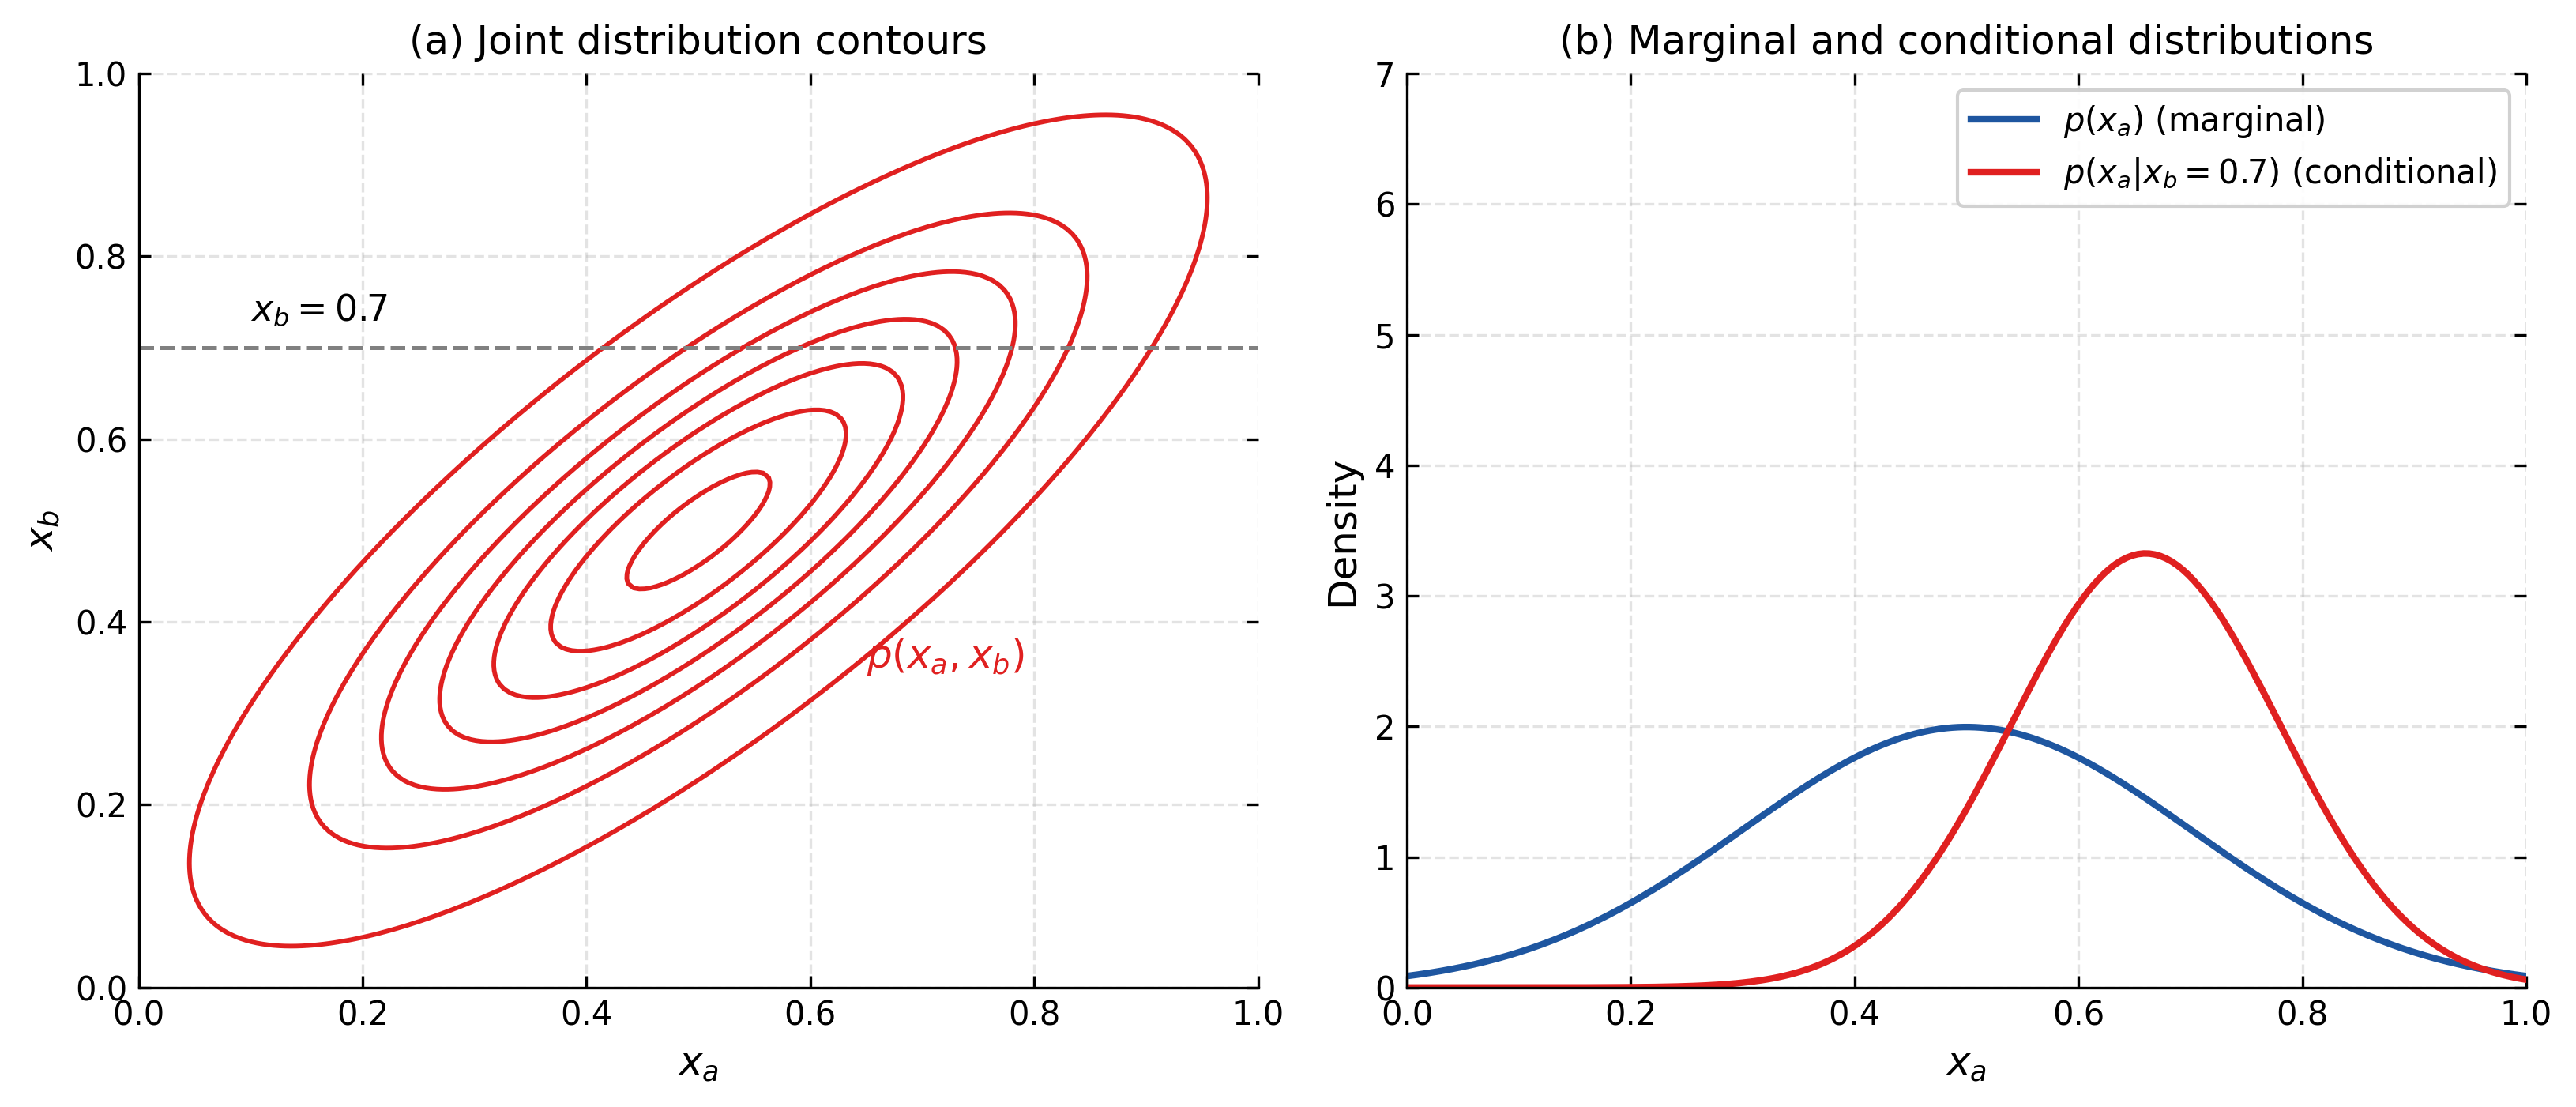

In [6]:
# 教科書 Figure 3.5 の完全再現: 同時分布の等高線と条件付き・周辺分布のスライス
fig3_5, axes3_5 = plot_figure_3_5(
    save_paths=get_save_paths('fig3_05_conditional_marginal.png'),
    show=True
)


<a id="sec_3_2_5"></a>
### 3.2.5 周辺ガウス分布 (Marginal Gaussian Distributions)

同時ガウス分布 $p(\mathbf{x}_a, \mathbf{x}_b)$ から $\mathbf{x}_b$ を積分消去（周辺化）した周辺確率分布 $p(\mathbf{x}_a)$ を求めます。

$$
p(\mathbf{x}_a) = \int_{\mathbb{R}^{D-M}} p(\mathbf{x}_a, \mathbf{x}_b) d\mathbf{x}_b \tag{3.81}
$$

同時密度の指数部において、$\mathbf{x}_b$ に関して平方完成を行います：
$$
\begin{aligned}
-\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Lambda} (\mathbf{x} - \boldsymbol{\mu})
&= -\frac{1}{2} (\mathbf{x}_b - \boldsymbol{\mu}_b + \boldsymbol{\Lambda}_{bb}^{-1}\boldsymbol{\Lambda}_{ba}(\mathbf{x}_a - \boldsymbol{\mu}_a))^T \boldsymbol{\Lambda}_{bb} (\mathbf{x}_b - \boldsymbol{\mu}_b + \boldsymbol{\Lambda}_{bb}^{-1}\boldsymbol{\Lambda}_{ba}(\mathbf{x}_a - \boldsymbol{\mu}_a)) \\
&\quad - \frac{1}{2} (\mathbf{x}_a - \boldsymbol{\mu}_a)^T (\boldsymbol{\Lambda}_{aa} - \boldsymbol{\Lambda}_{ab} \boldsymbol{\Lambda}_{bb}^{-1} \boldsymbol{\Lambda}_{ba}) (\mathbf{x}_a - \boldsymbol{\mu}_a)
\end{aligned}
$$

前半の $\mathbf{x}_b$ に関する積分を実行すると、ガウス積分により定数が生成され、後半の $\mathbf{x}_a$ の項のみが残ります。
ここでシューア補元の関係より：
$$
(\boldsymbol{\Lambda}_{aa} - \boldsymbol{\Lambda}_{ab} \boldsymbol{\Lambda}_{bb}^{-1} \boldsymbol{\Lambda}_{ba})^{-1} = \boldsymbol{\Sigma}_{aa}
$$
であるため、驚くほど簡潔な結果が得られます（式 3.82）：

$$
\mathbb{E}[\mathbf{x}_a] = \boldsymbol{\mu}_a \tag{3.82}
$$
$$
\text{cov}[\mathbf{x}_a] = \boldsymbol{\Sigma}_{aa} \tag{3.82}
$$

すなわち：
$$
p(\mathbf{x}_a) = \mathcal{N}(\mathbf{x}_a | \boldsymbol{\mu}_a, \boldsymbol{\Sigma}_{aa})
$$

#### 共分散形式と精度形式の美しい双対性 (Duality)
| 演算 | 表現に用いる形式 | 結果の簡潔さ |
| :--- | :--- | :--- |
| **条件付き分布 $p(\mathbf{x}_a \vert \mathbf{x}_b)$** | **精度行列 $\boldsymbol{\Lambda}$** | 精度行列は部分ブロック $\boldsymbol{\Lambda}_{aa}$ をそのまま取り出すだけ |
| **周辺分布 $p(\mathbf{x}_a)$** | **共分散行列 $\boldsymbol{\Sigma}$** | 共分散行列は部分ブロック $\boldsymbol{\Sigma}_{aa}$ をそのまま取り出すだけ |


In [7]:
# 条件付き分布と周辺分布の計算検証
mu = np.array([0.5, 0.5])
sigma = np.array([[0.04, 0.032], [0.032, 0.04]])
joint_g = MultivariateGaussian(mu=mu, sigma=sigma)

# 周辺分布 p(xa)
marginal_xa = joint_g.marginalize(indices_a=[0])
print("Marginal p(xa):")
print("  mean:", marginal_xa.mean[0], "(theoretical: 0.5)")
print("  var :", marginal_xa.covariance[0, 0], "(theoretical: 0.04)")

# 条件付き分布 p(xa | xb = 0.7)
xb_val = np.array([0.7])
cond_xa = joint_g.condition_on(indices_a=[0], indices_b=[1], x_b=xb_val)
print("\nConditional p(xa | xb = 0.7):")
print("  mean:", cond_xa.mean[0], "(theoretical: 0.5 + 0.032/0.04 * 0.2 = 0.66)")
print("  var :", cond_xa.covariance[0, 0], "(theoretical: 0.04 - 0.032^2/0.04 = 0.0144)")

assert np.isclose(marginal_xa.mean[0], 0.5)
assert np.isclose(marginal_xa.covariance[0, 0], 0.04)
assert np.isclose(cond_xa.mean[0], 0.66)
assert np.isclose(cond_xa.covariance[0, 0], 0.0144)
print("\n=> 条件付き・周辺分布の公式実装の正当性を確認しました。")


Marginal p(xa):
  mean: 0.5 (theoretical: 0.5)
  var : 0.04 (theoretical: 0.04)

Conditional p(xa | xb = 0.7):
  mean: 0.6599999999999999 (theoretical: 0.5 + 0.032/0.04 * 0.2 = 0.66)
  var : 0.0144 (theoretical: 0.04 - 0.032^2/0.04 = 0.0144)

=> 条件付き・周辺分布の公式実装の正当性を確認しました。


<a id="sec_3_2_6"></a>
### 3.2.6 ガウス変数に対するベイズの定理 (Bayes' Theorem for Gaussian Variables)

事前分布と尤度（観測モデル）が共に線形・ガウスであるとき、周辺分布および事後分布を解析的に求める一般的な定理を導出します。

#### 1. 線形ガウスモデルの設定
- **事前分布**:
  $$
  p(\mathbf{x}) = \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}, \boldsymbol{\Lambda}^{-1}) \tag{3.83}
  $$
- **観測モデル（条件付き分布）**:
  $$
  p(\mathbf{y} | \mathbf{x}) = \mathcal{N}(\mathbf{y} | \mathbf{A}\mathbf{x} + \mathbf{b}, \mathbf{L}^{-1}) \tag{3.84}
  $$
  ここで $\mathbf{x} \in \mathbb{R}^M$, $\mathbf{y} \in \mathbb{R}^D$, $\mathbf{A} \in \mathbb{R}^{D \times M}$ です。

#### 2. 同時分布 $p(\mathbf{z})$（$\mathbf{z} = (\mathbf{x}^T, \mathbf{y}^T)^T$）の導出
同時確率密度 $\ln p(\mathbf{z}) = \ln p(\mathbf{x}) + \ln p(\mathbf{y}|\mathbf{x})$ の指数部を展開します（式 3.85 - 3.88）：
$$
\begin{aligned}
&-\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Lambda}(\mathbf{x} - \boldsymbol{\mu}) - \frac{1}{2}(\mathbf{y} - \mathbf{A}\mathbf{x} - \mathbf{b})^T \mathbf{L}(\mathbf{y} - \mathbf{A}\mathbf{x} - \mathbf{b}) \\
&= -\frac{1}{2} \mathbf{x}^T (\boldsymbol{\Lambda} + \mathbf{A}^T \mathbf{L} \mathbf{A}) \mathbf{x} - \frac{1}{2} \mathbf{y}^T \mathbf{L} \mathbf{y} + \mathbf{x}^T \mathbf{A}^T \mathbf{L} \mathbf{y} + \mathbf{x}^T (\boldsymbol{\Lambda} \boldsymbol{\mu} - \mathbf{A}^T \mathbf{L} \mathbf{b}) + \mathbf{y}^T \mathbf{L} \mathbf{b} + \text{const}
\end{aligned}
$$

これを2次形式 $-\frac{1}{2} \mathbf{z}^T \mathbf{R} \mathbf{z} + \mathbf{z}^T \mathbf{h}$ と比較すると、同時分布の精度行列 $\mathbf{R}$ は（式 3.89）：
$$
\mathbf{R} = \begin{pmatrix} \boldsymbol{\Lambda} + \mathbf{A}^T \mathbf{L} \mathbf{A} & -\mathbf{A}^T \mathbf{L} \\ -\mathbf{L} \mathbf{A} & \mathbf{L} \end{pmatrix} \tag{3.89}
$$

この逆行列（共分散行列 $\text{cov}[\mathbf{z}]$）をブロック逆行列公式で計算すると（式 3.91, 3.92）：
$$
\text{cov}[\mathbf{z}] = \mathbf{R}^{-1} = \begin{pmatrix} \boldsymbol{\Lambda}^{-1} & \boldsymbol{\Lambda}^{-1} \mathbf{A}^T \\ \mathbf{A} \boldsymbol{\Lambda}^{-1} & \mathbf{L}^{-1} + \mathbf{A} \boldsymbol{\Lambda}^{-1} \mathbf{A}^T \end{pmatrix} \tag{3.92}
$$

---

#### 3. 周辺分布 $p(\mathbf{y})$ と事後分布 $p(\mathbf{x}|\mathbf{y})$
3.2.5節の周辺化の定理より、$\mathbf{y}$ の周辺分布は共分散行列の右下ブロックを直接読み取るだけで求まります（式 3.93, 3.94）：

$$
\mathbb{E}[\mathbf{y}] = \mathbf{A} \boldsymbol{\mu} + \mathbf{b} \tag{3.93}
$$
$$
\text{cov}[\mathbf{y}] = \mathbf{L}^{-1} + \mathbf{A} \boldsymbol{\Lambda}^{-1} \mathbf{A}^T = \mathbf{L}^{-1} + \mathbf{A} \boldsymbol{\Sigma} \mathbf{A}^T \tag{3.94}
$$

また、3.2.4節の条件付き分布の定理（式 3.73, 3.75）を精度行列 $\mathbf{R}$ に適用すると、事後分布 $p(\mathbf{x}|\mathbf{y})$ が求まります（式 3.97, 3.98）：

$$
\boldsymbol{\Sigma}_{\mathbf{x}|\mathbf{y}} = (\boldsymbol{\Lambda} + \mathbf{A}^T \mathbf{L} \mathbf{A})^{-1} \tag{3.98}
$$
$$
\boldsymbol{\mu}_{\mathbf{x}|\mathbf{y}} = \boldsymbol{\Sigma}_{\mathbf{x}|\mathbf{y}} \left\{ \mathbf{A}^T \mathbf{L} (\mathbf{y} - \mathbf{b}) + \boldsymbol{\Lambda} \boldsymbol{\mu} \right\} \tag{3.97}
$$

この結果は、カルマンフィルタの状態更新、ガウス過程回帰、ベイズ線形回帰の厳密な基礎方程式となっています。


In [8]:
# 線形ガウス・ベイズ更新のシミュレーション
np.random.seed(42)
# 2次元パラメータ x の事前分布
prior_mu = np.array([1.0, 2.0])
prior_cov = np.array([[1.5, 0.4], [0.4, 1.0]])
prior = MultivariateGaussian(mu=prior_mu, sigma=prior_cov)

# 観測方程式: y = A x + b + noise
A = np.array([[1.0, -2.0]])
b = np.array([0.5])
noise_cov = np.array([[0.2]])

# 観測値 y_obs = -1.2 が得られたとする
y_obs = np.array([-1.2])

marginal_y, posterior_x = MultivariateGaussian.bayes_linear_gaussian(
    prior=prior, A=A, b=b, L_cov=noise_cov, y_obs=y_obs
)

print("--- Prior p(x) ---")
print("  mu:", prior.mean)
print("  var diag:", np.diag(prior.covariance))

print("\n--- Marginal p(y) ---")
print("  mu:", marginal_y.mean[0])
print("  var:", marginal_y.covariance[0, 0])

print("\n--- Posterior p(x | y = -1.2) ---")
print("  mu:", posterior_x.mean)
print("  var diag:", np.diag(posterior_x.covariance))
print("  分散の減少比:", np.diag(posterior_x.covariance) / np.diag(prior.covariance))


--- Prior p(x) ---
  mu: [1. 2.]
  var diag: [1.5 1. ]

--- Marginal p(y) ---
  mu: -2.5
  var: 4.1000000000000005

--- Posterior p(x | y = -1.2) ---
  mu: [1.22195122 1.49268293]
  var diag: [1.3804878  0.37560976]
  分散の減少比: [0.9203252  0.37560976]


<a id="sec_3_2_7"></a>
### 3.2.7 ガウス分布の最尤推定 (Maximum Likelihood for the Gaussian)

独立同分布 (i.i.d.) に従う $N$ 個の観測データ集合 $\mathbf{X} = (\mathbf{x}_1, \dots, \mathbf{x}_N)^T \in \mathbb{R}^{N \times D}$ が与えられたとき、多変量ガウス分布のパラメータ $\boldsymbol{\mu}$ および $\boldsymbol{\Sigma}$ を最尤推定します。

#### 1. 対数尤度関数
対数尤度関数 $\ln p(\mathbf{X} | \boldsymbol{\mu}, \boldsymbol{\Sigma})$ は（式 3.103 - 3.105）：
$$
\ln p(\mathbf{X} | \boldsymbol{\mu}, \boldsymbol{\Sigma}) = -\frac{ND}{2} \ln(2\pi) - \frac{N}{2} \ln |\boldsymbol{\Sigma}| - \frac{1}{2} \sum_{n=1}^N (\mathbf{x}_n - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x}_n - \boldsymbol{\mu}) \tag{3.105}
$$

トレースの巡回不変性 $\mathbf{a}^T \mathbf{B} \mathbf{a} = \text{Tr}(\mathbf{a}^T \mathbf{B} \mathbf{a}) = \text{Tr}(\mathbf{B} \mathbf{a} \mathbf{a}^T)$ を用いると：
$$
\ln p(\mathbf{X} | \boldsymbol{\mu}, \boldsymbol{\Sigma}) = -\frac{ND}{2} \ln(2\pi) - \frac{N}{2} \ln |\boldsymbol{\Sigma}| - \frac{1}{2} \text{Tr} \left( \boldsymbol{\Sigma}^{-1} \sum_{n=1}^N (\mathbf{x}_n - \boldsymbol{\mu})(\mathbf{x}_n - \boldsymbol{\mu})^T \right)
$$

---

#### 2. 最尤推定量 $\boldsymbol{\mu}_{\text{ML}}$ の導出
$\boldsymbol{\mu}$ に関する勾配を計算し $0$ とおきます：
$$
\frac{\partial}{\partial \boldsymbol{\mu}} \ln p(\mathbf{X} | \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \sum_{n=1}^N \boldsymbol{\Sigma}^{-1} (\mathbf{x}_n - \boldsymbol{\mu}) = \mathbf{0}
$$
左から $\boldsymbol{\Sigma}$ を乗じることで（式 3.106）：
$$
\boldsymbol{\mu}_{\text{ML}} = \frac{1}{N} \sum_{n=1}^N \mathbf{x}_n \tag{3.106}
$$
最尤平均推定量は標本平均（sample mean）に一致します。

---

#### 3. 最尤推定量 $\boldsymbol{\Sigma}_{\text{ML}}$ の導出
行列微分の公式：
$$
\frac{\partial}{\partial \boldsymbol{\Sigma}} \ln |\boldsymbol{\Sigma}| = \boldsymbol{\Sigma}^{-1}, \quad
\frac{\partial}{\partial \boldsymbol{\Sigma}} \text{Tr}(\boldsymbol{\Sigma}^{-1} \mathbf{S}) = -\boldsymbol{\Sigma}^{-1} \mathbf{S} \boldsymbol{\Sigma}^{-1}
$$
を用いて、対数尤度の $\boldsymbol{\Sigma}$ に関する微分を計算し $0$ とおきます：
$$
\frac{\partial}{\partial \boldsymbol{\Sigma}} \ln p(\mathbf{X}) = -\frac{N}{2} \boldsymbol{\Sigma}^{-1} + \frac{1}{2} \boldsymbol{\Sigma}^{-1} \left( \sum_{n=1}^N (\mathbf{x}_n - \boldsymbol{\mu}_{\text{ML}})(\mathbf{x}_n - \boldsymbol{\mu}_{\text{ML}})^T \right) \boldsymbol{\Sigma}^{-1} = \mathbf{O}
$$
両側から $\boldsymbol{\Sigma}$ を乗じ、$N$ で割ることで（式 3.108）：
$$
\boldsymbol{\Sigma}_{\text{ML}} = \frac{1}{N} \sum_{n=1}^N (\mathbf{x}_n - \boldsymbol{\mu}_{\text{ML}})(\mathbf{x}_n - \boldsymbol{\mu}_{\text{ML}})^T \tag{3.108}
$$

---

#### 4. 推定量のバイアス（偏り）分析
期待値を計算すると：
$$
\mathbb{E}[\boldsymbol{\mu}_{\text{ML}}] = \boldsymbol{\mu} \quad (\text{不偏推定量})
$$
しかし共分散推定量には標本平均の使用による自由度の損失が生じます：
$$
\mathbb{E}[\boldsymbol{\Sigma}_{\text{ML}}] = \frac{N - 1}{N} \boldsymbol{\Sigma} \quad (\text{過小評価バイアス})
$$
したがって、不偏共分散推定量 $\widetilde{\boldsymbol{\Sigma}}$ は $N-1$ で割ったものになります（式 3.109）：
$$
\widetilde{\boldsymbol{\Sigma}} = \frac{1}{N - 1} \sum_{n=1}^N (\mathbf{x}_n - \boldsymbol{\mu}_{\text{ML}})(\mathbf{x}_n - \boldsymbol{\mu}_{\text{ML}})^T \tag{3.109}
$$


In [9]:
# 最尤共分散推定量のバイアス数値シミュレーション
np.random.seed(42)
D = 2
true_cov = np.array([[2.0, 0.8], [0.8, 1.5]])
true_m = np.array([0.0, 0.0])
true_dist = MultivariateGaussian(mu=true_m, sigma=true_cov)

N_samples = 4  # 極小サンプルサイズでバイアスを顕著に観察
num_trials = 20000

mle_covs = np.zeros((num_trials, D, D))
unbiased_covs = np.zeros((num_trials, D, D))

for t in range(num_trials):
    X = true_dist.sample(size=N_samples)
    mle_covs[t] = MultivariateGaussian.fit_mle(X, unbiased_cov=False).covariance
    unbiased_covs[t] = MultivariateGaussian.fit_mle(X, unbiased_cov=True).covariance

mean_mle = np.mean(mle_covs, axis=0)
mean_unbiased = np.mean(unbiased_covs, axis=0)

print(f"真の共分散行列 (N = {N_samples}):\n", true_cov)
print(f"最尤推定量 E[Sigma_ML]:\n", np.round(mean_mle, 4))
print(f"理論上の過小期待値 (N-1)/N * Sigma:\n", np.round((N_samples - 1) / N_samples * true_cov, 4))
print(f"不偏推定量 E[Sigma_tilde]:\n", np.round(mean_unbiased, 4))


真の共分散行列 (N = 4):
 [[2.  0.8]
 [0.8 1.5]]
最尤推定量 E[Sigma_ML]:
 [[1.5025 0.599 ]
 [0.599  1.1171]]
理論上の過小期待値 (N-1)/N * Sigma:
 [[1.5   0.6  ]
 [0.6   1.125]]
不偏推定量 E[Sigma_tilde]:
 [[2.0033 0.7986]
 [0.7986 1.4894]]


<a id="sec_3_2_8"></a>
### 3.2.8 逐次推定 (Sequential Estimation)

大規模データやオンライン・リアルタイムストリーミング環境では、全データ点をメモリに保持して一括（バッチ）推定することは不可能です。新しいデータ点 $\mathbf{x}_N$ が到着するたびに推定量を更新する **逐次推定 (sequential estimation / online learning)** が必須となります。

最尤平均推定量 $\boldsymbol{\mu}^{(N)}$ について、$N$ 番目の項を分離します：
$$
\begin{aligned}
\boldsymbol{\mu}^{(N)} &= \frac{1}{N} \sum_{n=1}^N \mathbf{x}_n \\
&= \frac{1}{N} \mathbf{x}_N + \frac{1}{N} \sum_{n=1}^{N-1} \mathbf{x}_n \\
&= \frac{1}{N} \mathbf{x}_N + \frac{N - 1}{N} \boldsymbol{\mu}^{(N-1)} \\
&= \boldsymbol{\mu}^{(N-1)} + \frac{1}{N} (\mathbf{x}_N - \boldsymbol{\mu}^{(N-1)}) \tag{3.110}
\end{aligned}
$$

この更新式は、深層学習における **確率的勾配降下法 (SGD)** や **ロビンス・モンロー (Robbins-Monro) アルゴリズム**：
$$
\theta^{(N)} = \theta^{(N-1)} - a_N \nabla L(\theta^{(N-1)})
$$
の厳密な具現化です。学習率（ステップサイズ） $\alpha_N = 1/N$ は、ロビンス・モンローの収束条件：
$$
\sum_{N=1}^\infty \alpha_N = \infty, \quad \sum_{N=1}^\infty \alpha_N^2 < \infty
$$
を完全に満たしており、真の平均への概収束が数学的に保証されています。


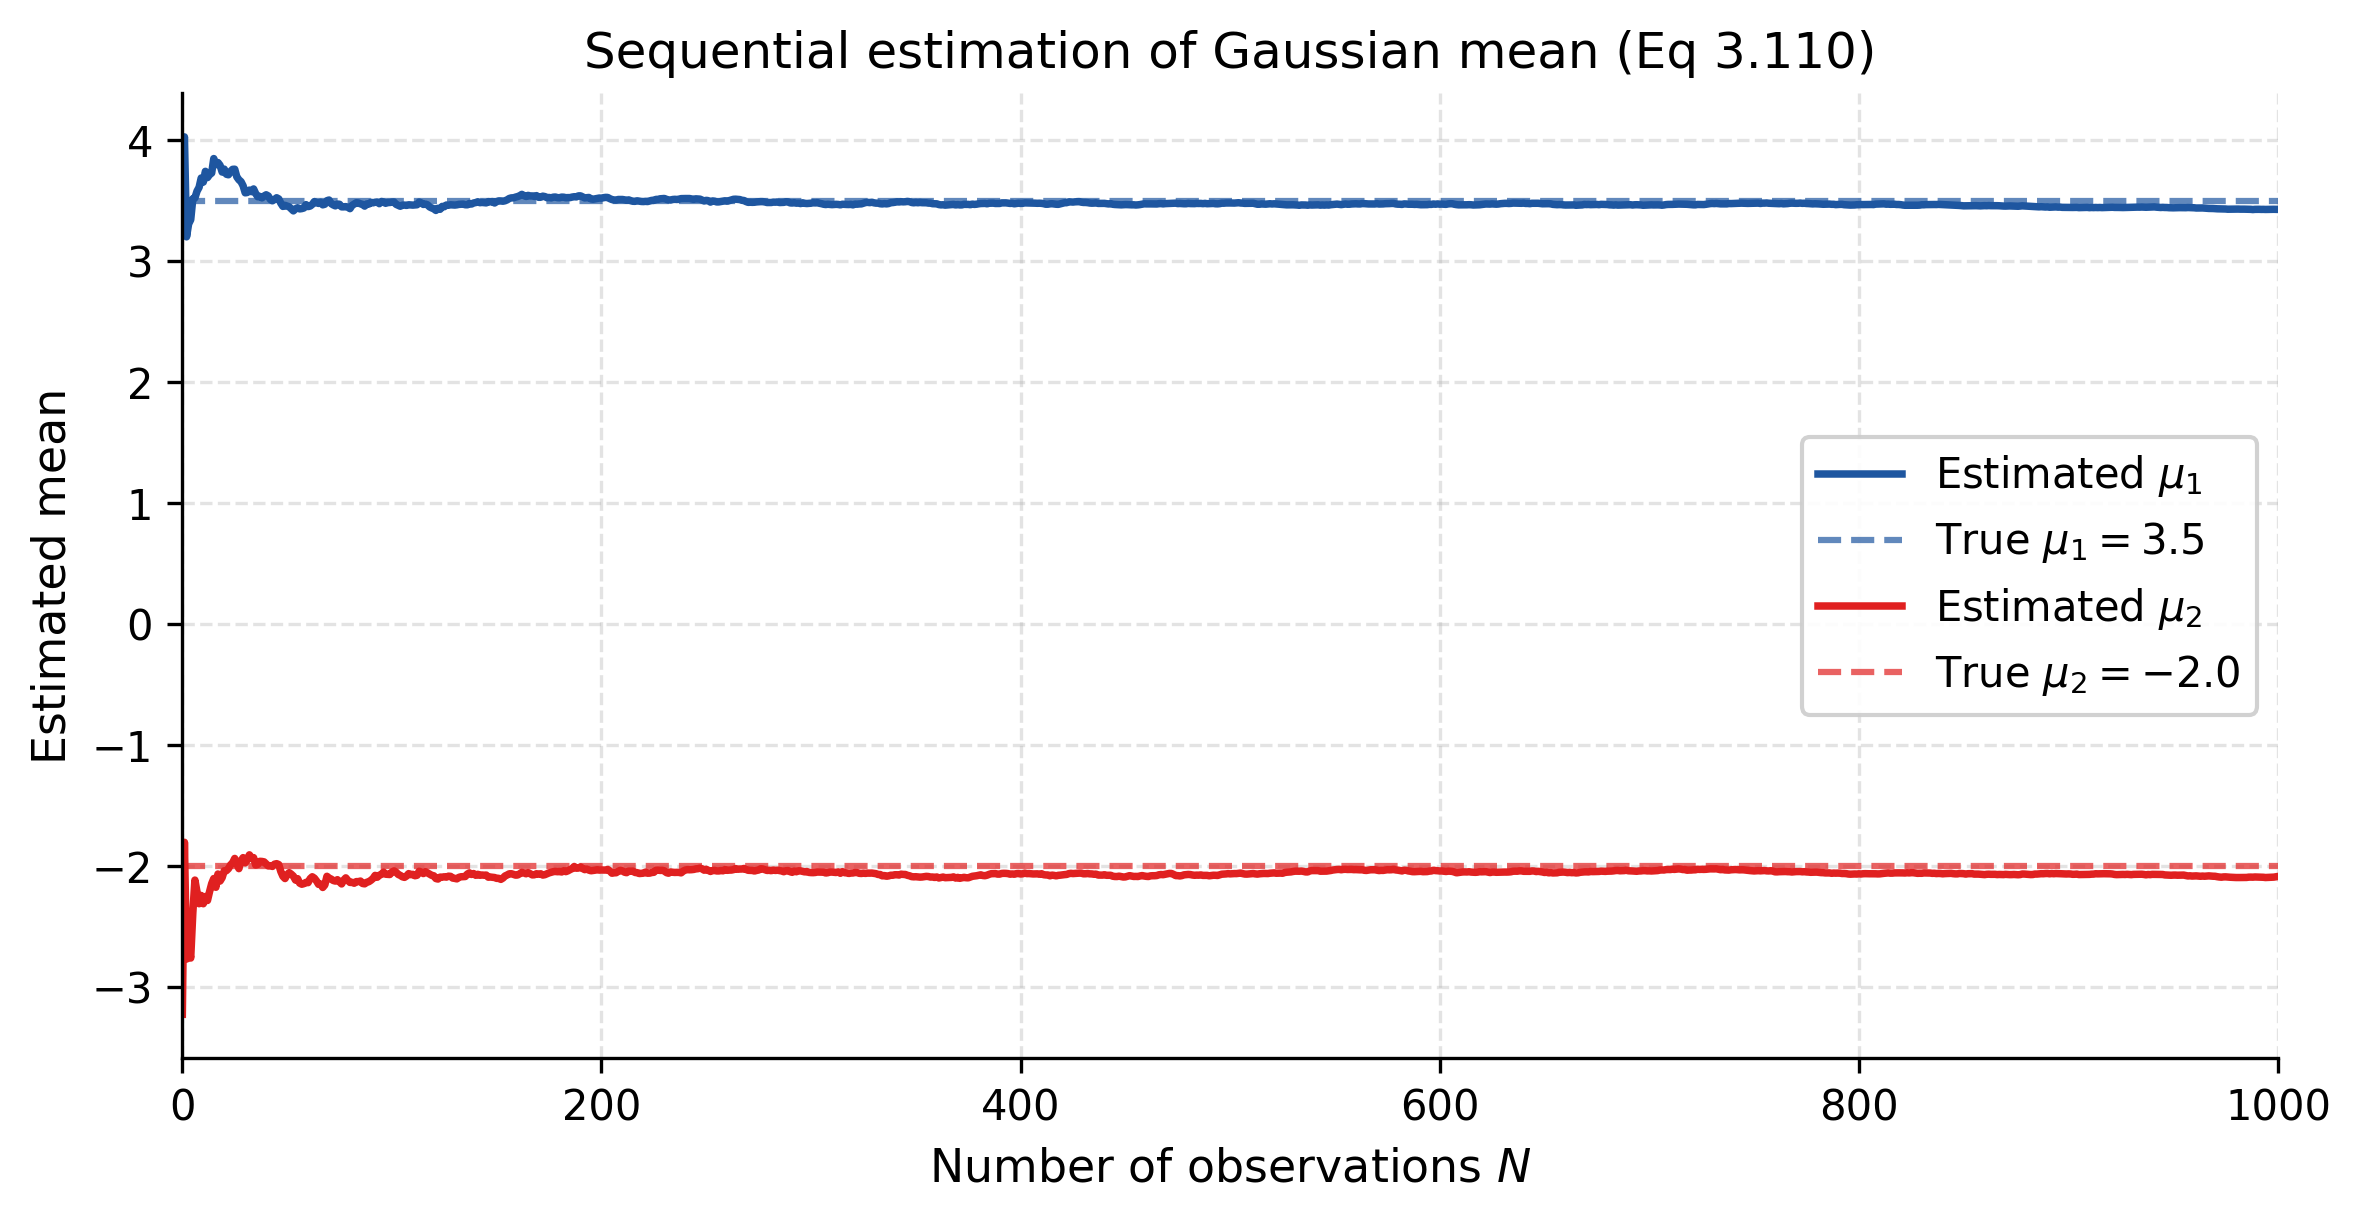

In [10]:
# 逐次推定のシミュレーション
np.random.seed(42)
true_mean = np.array([3.5, -2.0])
true_cov = np.array([[1.0, 0.5], [0.5, 2.0]])
g_gen = MultivariateGaussian(mu=true_mean, sigma=true_cov)

data_stream = g_gen.sample(size=1000, seed=42)

running_mu = data_stream[0].copy()
mu_history = [running_mu.copy()]

for n in range(1, len(data_stream)):
    running_mu = MultivariateGaussian.sequential_mean_update(
        mu_old=running_mu, x_new=data_stream[n], N=n+1
    )
    mu_history.append(running_mu.copy())

mu_history = np.array(mu_history)

fig, ax = plt.subplots(figsize=(8, 4.2), dpi=300)
ax.plot(mu_history[:, 0], label=r'Estimated $\mu_1$', color='#1E56A0', lw=1.8)
ax.axhline(true_mean[0], color='#1E56A0', linestyle='--', alpha=0.7, label=r'True $\mu_1 = 3.5$')
ax.plot(mu_history[:, 1], label=r'Estimated $\mu_2$', color='#E02020', lw=1.8)
ax.axhline(true_mean[1], color='#E02020', linestyle='--', alpha=0.7, label=r'True $\mu_2 = -2.0$')

ax.set_xlim(0, 1000)
ax.set_xlabel('Number of observations $N$', fontsize=11)
ax.set_ylabel('Estimated mean', fontsize=11)
ax.set_title('Sequential estimation of Gaussian mean (Eq 3.110)', fontsize=12)
ax.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=10)
plt.tight_layout()
plt.show()


<a id="sec_3_2_9"></a>
### 3.2.9 ガウス混合モデル (Mixtures of Gaussians)

単一のガウス分布が持つ単峰性の限界を克服するため、$K$ 個のガウス分布を線形結合（重ね合わせ）した **ガウス混合モデル (Gaussian Mixture Model: GMM)** を導入します。

#### 1. モデルの定義
$$
p(\mathbf{x}) = \sum_{k=1}^K \pi_k \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k) \tag{3.111}
$$
ここで $\pi_k$ は **混合係数 (mixing coefficients)** であり、確率の公理を満たします（式 3.112, 3.113）：
$$
\sum_{k=1}^K \pi_k = 1, \quad 0 \le \pi_k \le 1 \tag{3.112, 3.113}
$$

---

#### 2. 潜在変数モデルと負担率 (Responsibilities)
$K$ 次元の 1-of-$K$ 表現をとる離散潜在変数 $\mathbf{z} \in \{0, 1\}^K$（$\sum_k z_k = 1$）を導入します：
- 事前確率: $p(z_k = 1) = \pi_k$
- 条件付き分布: $p(\mathbf{x} | z_k = 1) = \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$

観測 $\mathbf{x}$ が与えられたとき、それが第 $k$ 成分から生成された事後確率を **負担率 (responsibility)** $\gamma(z_k) \equiv p(z_k = 1 | \mathbf{x})$ と呼び、ベイズの定理によって求まります（式 3.119）：
$$
\gamma_k(\mathbf{x}) = p(z_k = 1 | \mathbf{x}) = \frac{\pi_k \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_{j=1}^K \pi_j \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)} \tag{3.119}
$$

---

#### 3. EMアルゴリズム (Expectation-Maximization)
GMMの対数尤度関数は $\sum_n \ln \sum_k \dots$ のように対数の中に和が入るため、解析的な最尤解は存在しません。さらに、ある成分の平均が特定のデータ点に一致し分散が $0$ に近づくと、尤度が無限大に発散する **特異解 (singularity)** の問題が存在します。

これに対し、反復法である **EMアルゴリズム** を用いて局所最適解を求めます：
- **Eステップ (Expectation)**:
  現在のパラメータを用いて、各データ点 $n$ に対する各成分 $k$ の負担率 $\gamma_{nk} = \gamma_k(\mathbf{x}_n)$ を計算（式 3.119）。
- **Mステップ (Maximization)**:
  負担率を用いてパラメータを再推定：
  $$
  N_k = \sum_{n=1}^N \gamma_{nk} \tag{3.115}
  $$
  $$
  \boldsymbol{\mu}_k^{\text{new}} = \frac{1}{N_k} \sum_{n=1}^N \gamma_{nk} \mathbf{x}_n \tag{3.117}
  $$
  $$
  \boldsymbol{\Sigma}_k^{\text{new}} = \frac{1}{N_k} \sum_{n=1}^N \gamma_{nk} (\mathbf{x}_n - \boldsymbol{\mu}_k^{\text{new}})(\mathbf{x}_n - \boldsymbol{\mu}_k^{\text{new}})^T \tag{3.118}
  $$
  $$
  \pi_k^{\text{new}} = \frac{N_k}{N} \tag{3.116}
  $$


Figure 3.6 saved successfully to: result/fig3_06_old_faithful_gaussian_and_mixture.png
Figure 3.6 saved successfully to: ../result/fig3_06_old_faithful_gaussian_and_mixture.png


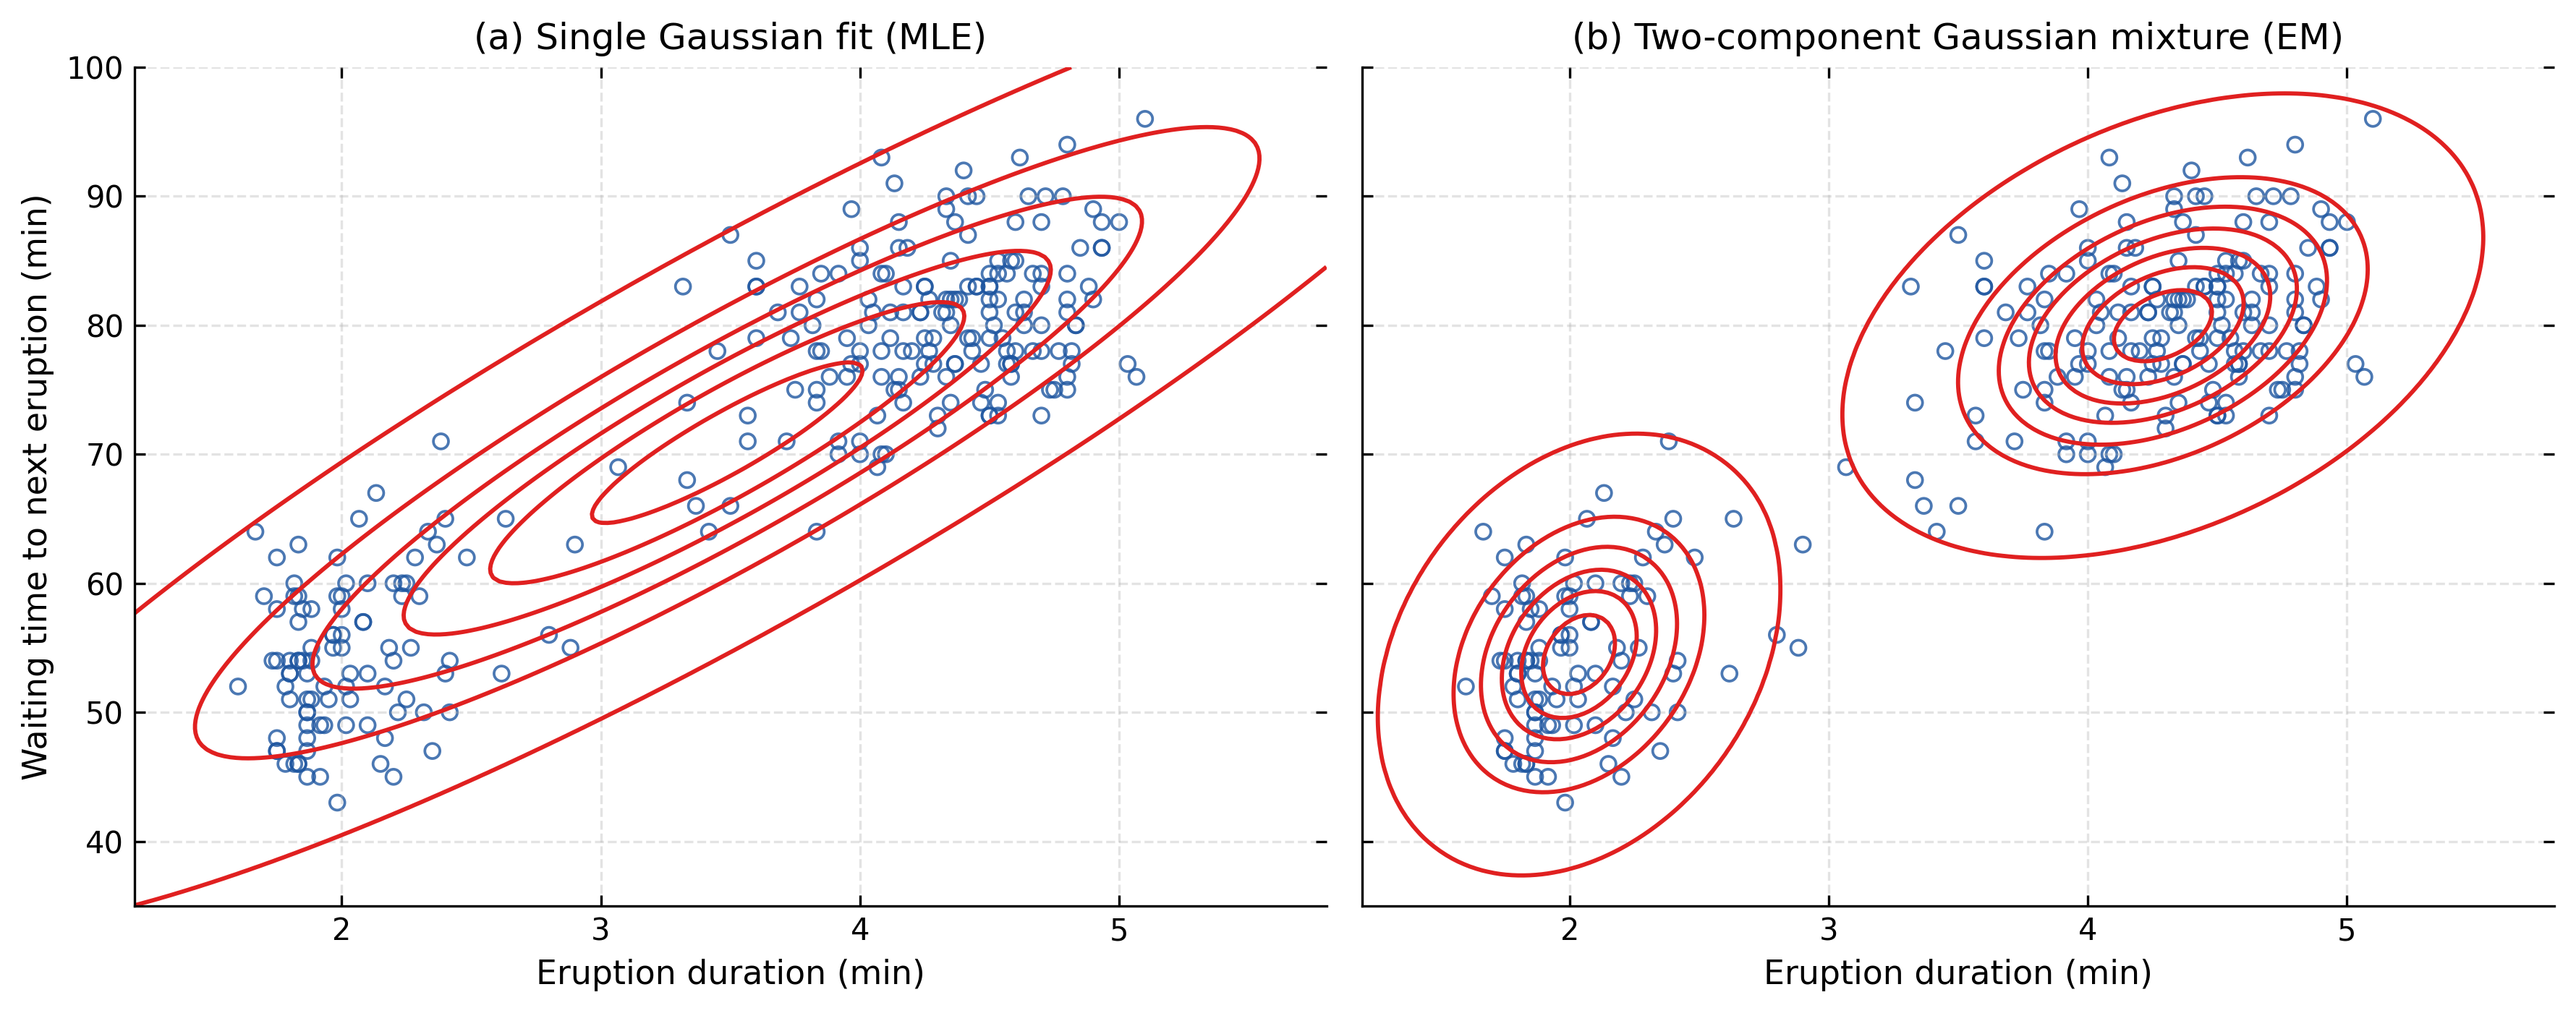

In [11]:
# 教科書 Figure 3.6 の完全再現: Old Faithful 間欠泉データ
# (a) 単一ガウス最尤推定 vs (b) 2成分ガウス混合モデル (EM)
fig3_6, axes3_6 = plot_figure_3_6(
    data_path=get_data_path('faithful.csv'),
    save_paths=get_save_paths('fig3_06_old_faithful_gaussian_and_mixture.png'),
    show=True
)


Figure 3.7 saved successfully to: result/fig3_07_gaussian_mixture_1d.png
Figure 3.7 saved successfully to: ../result/fig3_07_gaussian_mixture_1d.png


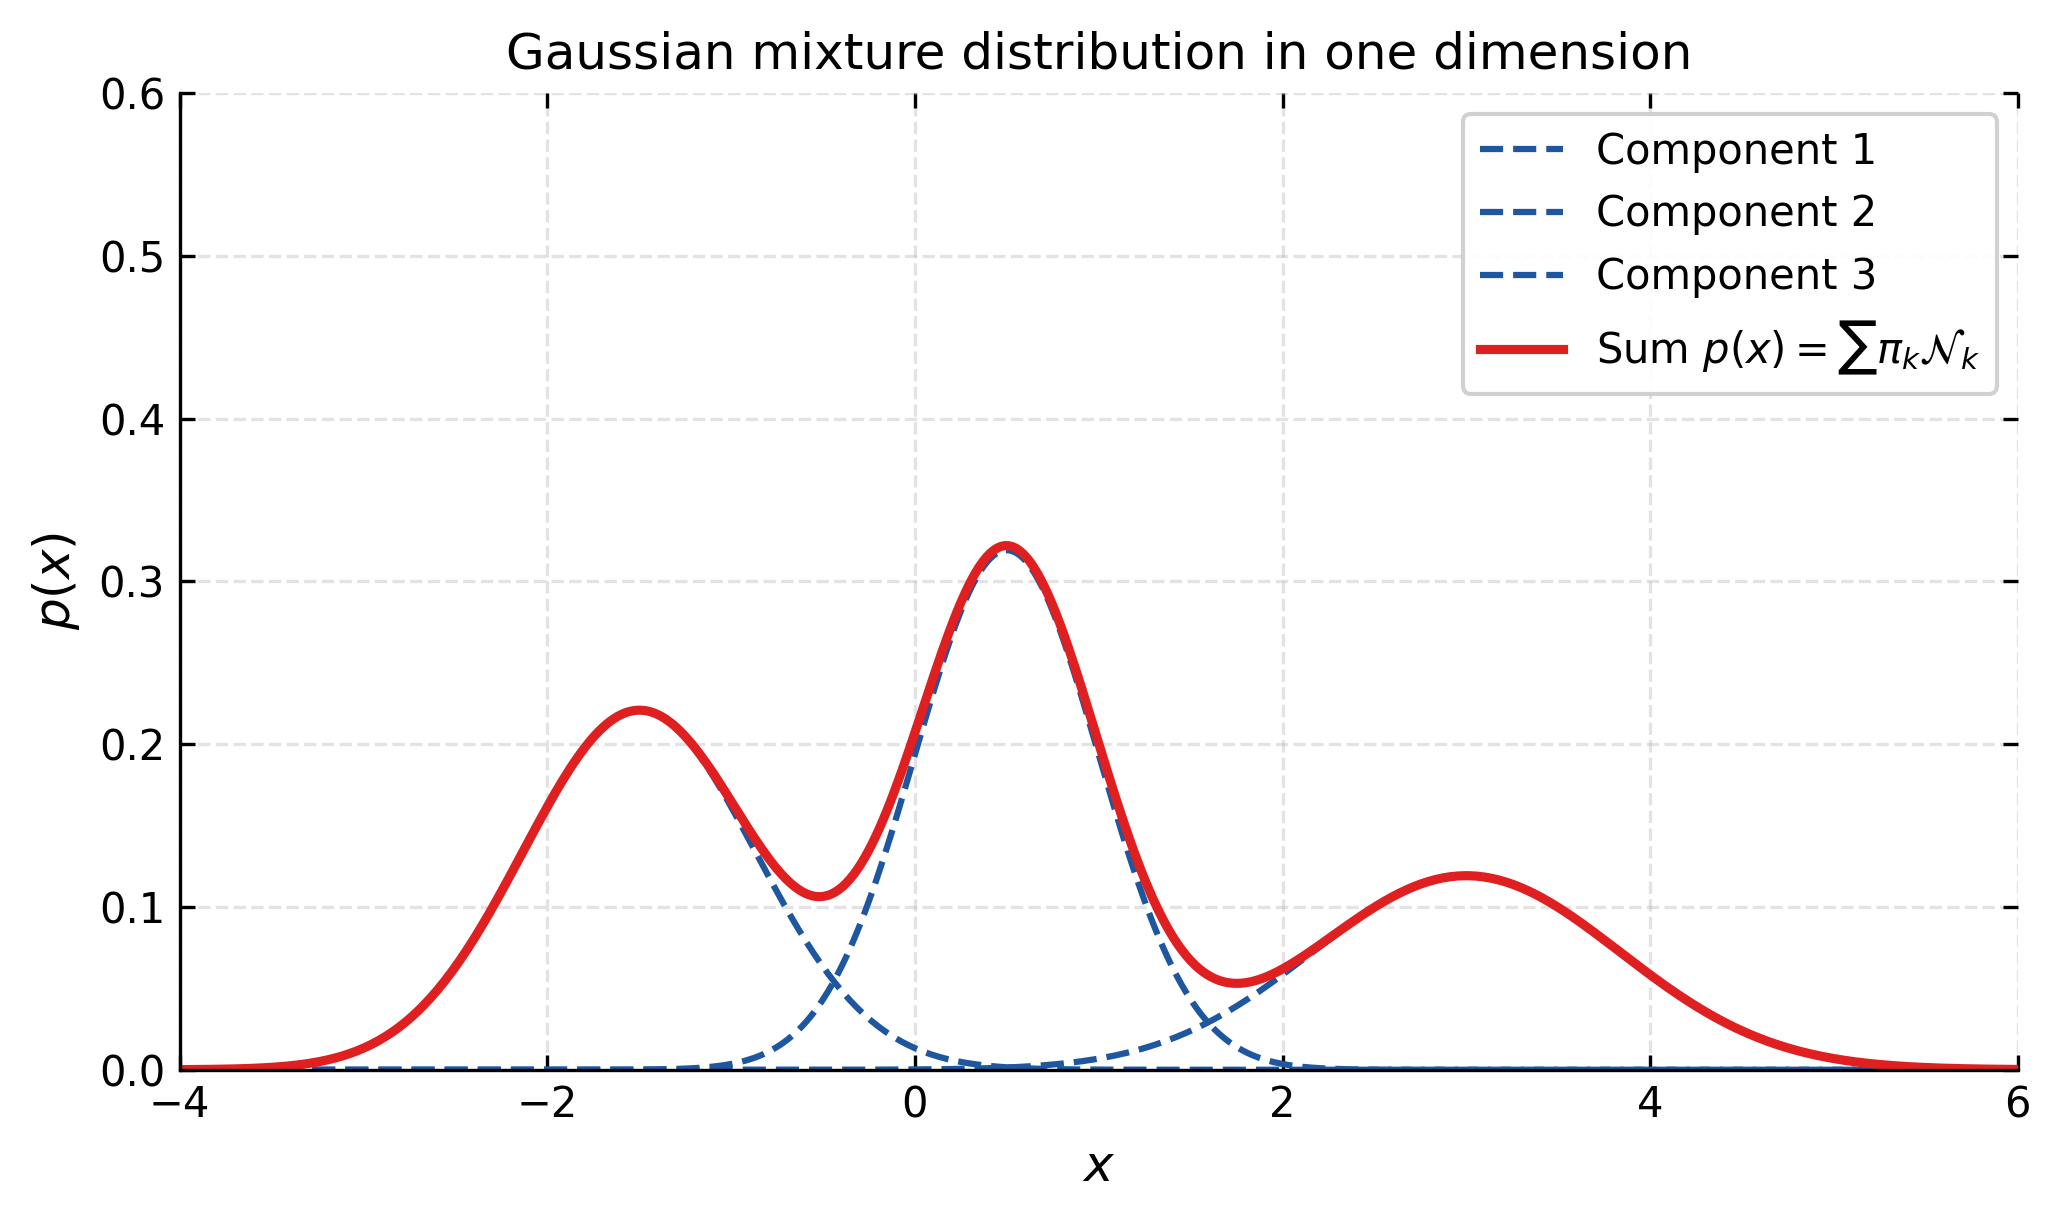

In [12]:
# 教科書 Figure 3.7 の完全再現: 1次元ガウス混合分布
# 3つの青色破線成分 pi_k * N_k と、その和である赤色実線混合分布
fig3_7, ax3_7 = plot_figure_3_7(
    save_paths=get_save_paths('fig3_07_gaussian_mixture_1d.png'),
    show=True
)


Figure 3.8 saved successfully to: result/fig3_08_gaussian_mixture_2d.png


Figure 3.8 saved successfully to: ../result/fig3_08_gaussian_mixture_2d.png


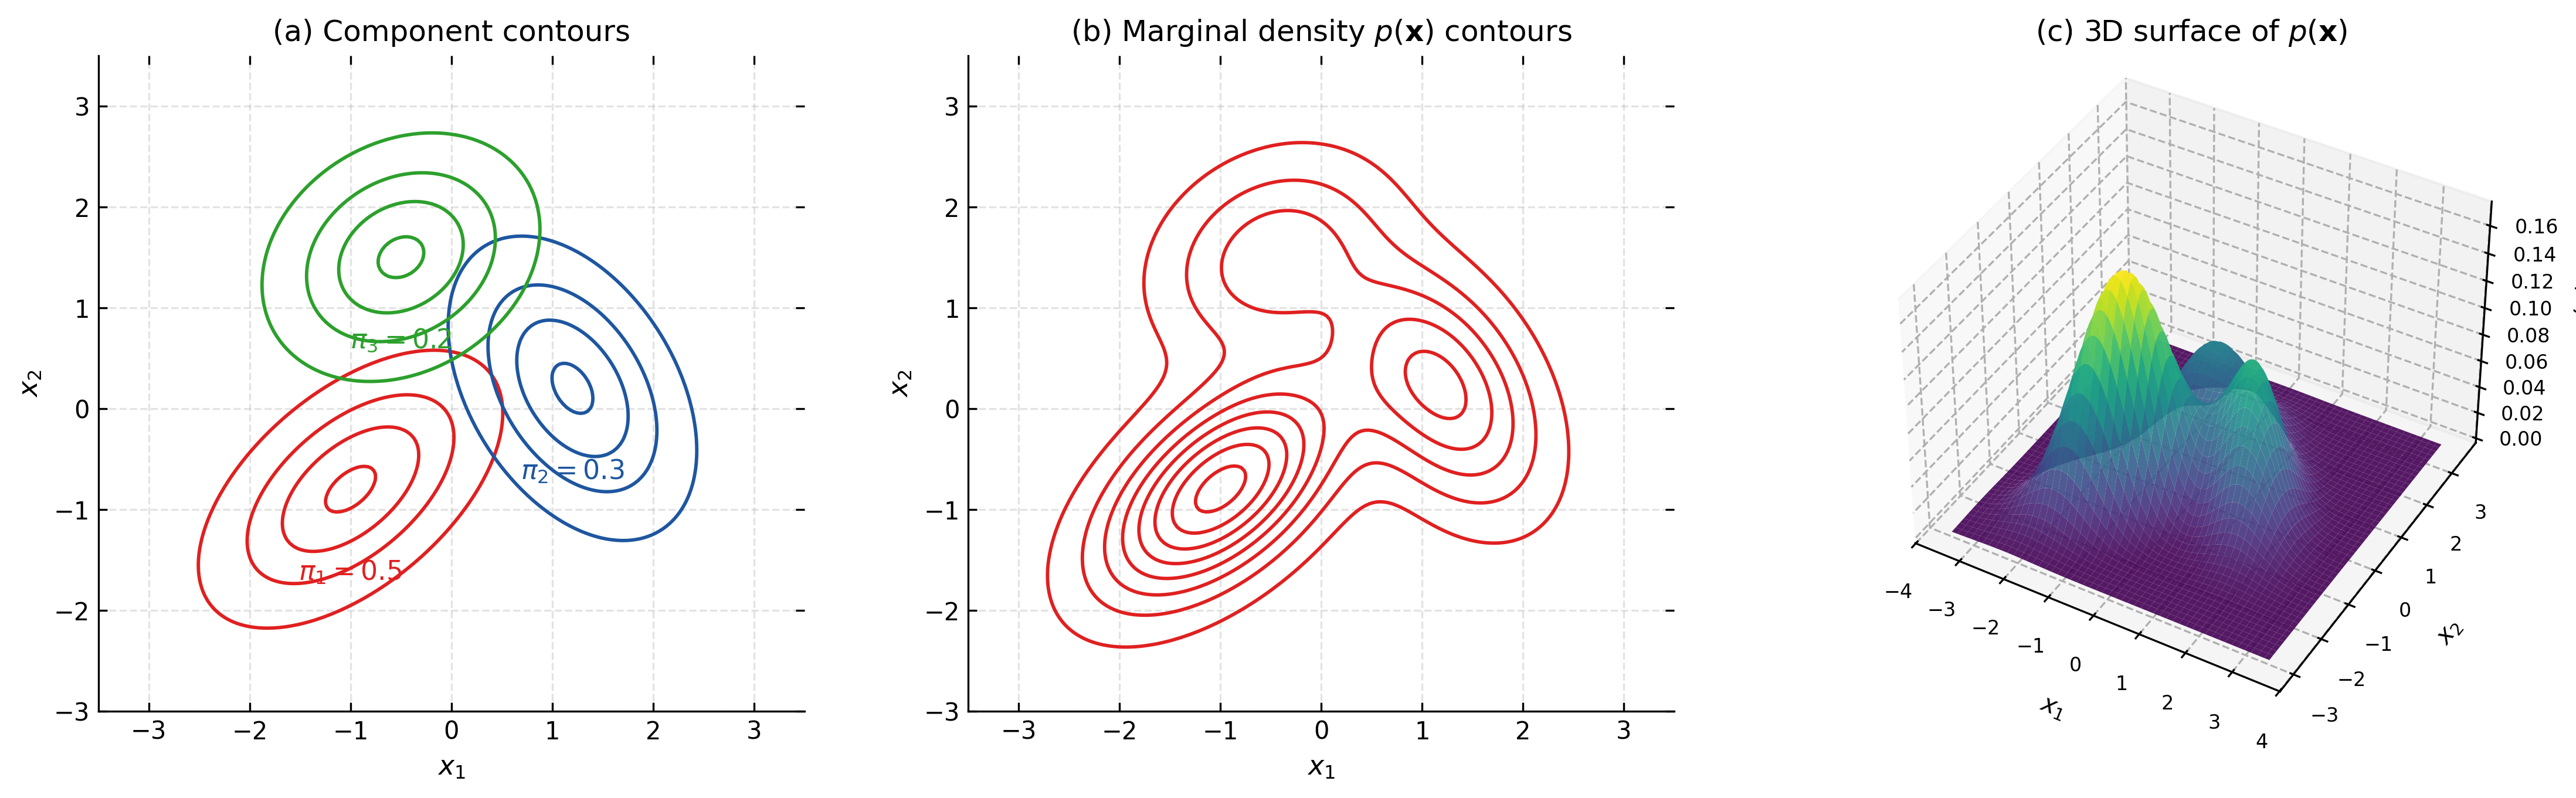

In [13]:
# 教科書 Figure 3.8 の完全再現: 2次元3成分ガウス混合モデル
# (a) 各成分の等高線と混合重み pi_1=0.5, pi_2=0.3, pi_3=0.2
# (b) 混合確率密度 p(x) の等高線
# (c) p(x) の 3D 曲面プロット
fig3_8, axes3_8 = plot_figure_3_8(
    save_paths=get_save_paths('fig3_08_gaussian_mixture_2d.png'),
    show=True
)


<a id="sec_summary"></a>
### まとめと展望 (Summary and Outlook)

#### 本節 (3.2 多変量ガウス分布) の重要知見まとめ
1. **幾何学的構造**:
   マハラノビス距離 $\Delta^2 = (\mathbf{x}-\boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})$ の等高面は楕円面を成し、共分散行列の固有ベクトルが主軸方向、固有値の平方根 $\lambda_i^{1/2}$ が主軸半径を与えます。
2. **閉じた解析的演算**:
   - **条件付き分布**: $p(\mathbf{x}_a | \mathbf{x}_b) = \mathcal{N}(\boldsymbol{\mu}_{a|b}, \boldsymbol{\Sigma}_{a|b})$ は精度行列 $\boldsymbol{\Lambda}_{aa}^{-1}$ を通じて即座に導出され、分散は $\mathbf{x}_b$ に依存しません。
   - **周辺分布**: $p(\mathbf{x}_a) = \mathcal{N}(\boldsymbol{\mu}_a, \boldsymbol{\Sigma}_{aa})$ は共分散行列の部分ブロックを直接読み取るだけで求まります。
   - **ベイズの定理**: 線形ガウス事前分布と線形ガウス観測モデルに対し、事後分布と周辺分布も厳密にガウス分布となります。
3. **推定と学習**:
   - 最尤推定量 $\boldsymbol{\Sigma}_{\text{ML}}$ は過小評価バイアス（$(N-1)/N$ 倍）を持ち、不偏共分散推定量 $\widetilde{\boldsymbol{\Sigma}}$ は $N-1$ で割ることで得られます。
   - 逐次推定 $\boldsymbol{\mu}^{(N)} = \boldsymbol{\mu}^{(N-1)} + \frac{1}{N}(\mathbf{x}_N - \boldsymbol{\mu}^{(N-1)})$ はオンライン学習・SGDの原点です。
4. **ガウス混合モデル (GMM)**:
   潜在変数とEMアルゴリズムにより多峰性分布を柔軟に表現可能であり、深層学習における変分オートエンコーダ (VAE) や潜在変数モデルの基礎となっています。

---

#### 次節 (3.3 周期変数 / Periodic Variables) への展望
風向、日周・年周期、時計の針、分子の結合角など、円周上や周期的な境界条件を持つ連続データに対して通常のガウス分布を直接適用すると、境界（$0$ と $2\pi$）で不連続性が生じ、深刻なモデリングの破綻を引き起こします。
次節 **3.3 周期変数 (Periodic Variables)** では、極座標への変換や単位円上のガウス分布の条件付けを通じて、方向統計学の基礎となる **フォン・ミーゼス分布 (von Mises distribution)** を探究します。
